# **CELL 1: Setup and Import Libraries**


In [2]:
# ============================================================
# CELL 1: Import Required Libraries
# ============================================================
# This cell imports all necessary libraries for the project.
# Run this cell first.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# For URL processing
import re
import urllib.parse
from urllib.parse import urlparse
import math
from collections import Counter

# For machine learning
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_recall_curve, auc, brier_score_loss
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# For gradient boosting
import xgboost as xgb
import lightgbm as lgb

# For explainability
import shap

# For saving models
import joblib
import pickle

print("✅ All libraries imported successfully!")
print(f"SHAP version: {shap.__version__}")

✅ All libraries imported successfully!
SHAP version: 0.51.0


# **CELL 2: Load Datasets**


In [3]:
# ============================================================
# CELL 2: Load All Datasets (FINAL CORRECTED PATHS)
# ============================================================
# This cell loads the three datasets from Kaggle.
# CORRECT PATH: /kaggle/input/datasets/sishahed/phshing-link-scoring-datasets/

import os
import pandas as pd

# Set the base path
BASE_PATH = '/kaggle/input/datasets/sishahed/phshing-link-scoring-datasets/'

print("Loading datasets from Kaggle input...")
print("=" * 60)
print(f"Base path: {BASE_PATH}")

# Check if directory exists
if os.path.exists(BASE_PATH):
    print(f"✅ Directory exists!")
    print(f"Files in directory: {os.listdir(BASE_PATH)}")
else:
    print(f"❌ Directory not found!")
    # Try alternative paths
    alternatives = [
        '/kaggle/input/datasets/',
        '/kaggle/input/',
        '/kaggle/working/'
    ]
    for alt in alternatives:
        if os.path.exists(alt):
            print(f"Found alternative: {alt}")
            print(f"Files: {os.listdir(alt)}")

print("\n" + "=" * 60)

# Dataset 1: Majestic Million (Benign URLs)
print("\n1. Loading Majestic Million...")
try:
    majestic_df = pd.read_csv(BASE_PATH + 'majestic_million.csv')
    print(f"   ✅ Loaded successfully!")
    print(f"   Shape: {majestic_df.shape}")
    print(f"   Columns: {majestic_df.columns.tolist()}")
    print(f"   First 3 rows:\n{majestic_df.head(3)}")
except Exception as e:
    print(f"   ❌ Error: {e}")

# Dataset 2: Malicious URLs Dataset
print("\n2. Loading Malicious URLs Dataset...")
try:
    malicious_df = pd.read_csv(BASE_PATH + 'malicious_phish.csv')
    print(f"   ✅ Loaded successfully!")
    print(f"   Shape: {malicious_df.shape}")
    print(f"   Columns: {malicious_df.columns.tolist()}")
    if 'type' in malicious_df.columns:
        print(f"   Type distribution:")
        print(malicious_df['type'].value_counts())
    print(f"   First 3 rows:\n{malicious_df.head(3)}")
except Exception as e:
    print(f"   ❌ Error: {e}")

# Dataset 3: PhiUSIIL Phishing URL Dataset
print("\n3. Loading PhiUSIIL Dataset...")
try:
    phiusiil_df = pd.read_csv(BASE_PATH + 'PhiUSIIL_Phishing_URL_Dataset.csv')
    print(f"   ✅ Loaded successfully!")
    print(f"   Shape: {phiusiil_df.shape}")
    print(f"   Columns (first 10): {phiusiil_df.columns.tolist()[:10]}")
    if 'label' in phiusiil_df.columns:
        print(f"   Label distribution:")
        print(phiusiil_df['label'].value_counts())
    print(f"   First 3 rows:\n{phiusiil_df.head(3)}")
except Exception as e:
    print(f"   ❌ Error: {e}")

print("\n" + "=" * 60)
print("✅ All datasets loaded successfully!")

# Store path for later use
DATASET_PATH = BASE_PATH
print(f"\nDataset path saved as: {DATASET_PATH}")

Loading datasets from Kaggle input...
Base path: /kaggle/input/datasets/sishahed/phshing-link-scoring-datasets/
✅ Directory exists!
Files in directory: ['PhiUSIIL_Phishing_URL_Dataset.csv', 'majestic_million.csv', 'malicious_phish.csv']


1. Loading Majestic Million...
   ✅ Loaded successfully!
   Shape: (1000000, 12)
   Columns: ['GlobalRank', 'TldRank', 'Domain', 'TLD', 'RefSubNets', 'RefIPs', 'IDN_Domain', 'IDN_TLD', 'PrevGlobalRank', 'PrevTldRank', 'PrevRefSubNets', 'PrevRefIPs']
   First 3 rows:
   GlobalRank  TldRank        Domain  TLD  RefSubNets   RefIPs    IDN_Domain  \
0           1        1    google.com  com      507303  2239843    google.com   
1           2        2  facebook.com  com      478234  2245199  facebook.com   
2           3        3   youtube.com  com      432423  1853624   youtube.com   

  IDN_TLD  PrevGlobalRank  PrevTldRank  PrevRefSubNets  PrevRefIPs  
0     com               1            1          508097     2242643  
1     com               2          

# **CELL 3: URL Normalization Function**

In [4]:
# ============================================================
# CELL 3: URL Normalization Function
# ============================================================
# This function normalizes URLs for consistent processing.

import urllib.parse
import re

def normalize_url(url):
    """
    Normalize a URL while preserving important features for phishing detection.
    
    Args:
        url: URL string
        
    Returns:
        Normalized URL string
    """
    if not isinstance(url, str):
        return ""
    
    # Remove leading/trailing whitespace
    url = url.strip()
    
    if url == "":
        return ""
    
    try:
        # If URL doesn't have scheme, add http:// for parsing
        if not url.startswith(('http://', 'https://')):
            url = 'http://' + url
        
        # Convert to lowercase for consistent comparison
        url_lower = url.lower()
        
        # Parse URL
        parsed = urllib.parse.urlparse(url_lower)
        
        # Normalize scheme
        scheme = parsed.scheme if parsed.scheme else "http"
        
        # Normalize hostname (lowercase, remove www)
        hostname = parsed.hostname if parsed.hostname else ""
        if hostname.startswith("www."):
            hostname = hostname[4:]
        
        # Normalize path (remove trailing slash for consistency)
        path = parsed.path if parsed.path else ""
        if path.endswith("/"):
            path = path[:-1]
        
        # Keep query and fragment as-is
        query = parsed.query if parsed.query else ""
        fragment = parsed.fragment if parsed.fragment else ""
        
        # Reconstruct URL
        normalized = f"{scheme}://{hostname}{path}"
        if query:
            normalized += f"?{query}"
        if fragment:
            normalized += f"#{fragment}"
        
        return normalized
    except:
        return url

# Test the function
test_urls = [
    "https://www.google.com/",
    "http://google.com",
    "HTTPS://GOOGLE.COM/",
    "https://login.example.com/login.php?redirect=home",
    "google.com",
    "www.facebook.com"
]

print("URL Normalization Test:")
print("=" * 60)
for url in test_urls:
    normalized = normalize_url(url)
    print(f"Original:    {url}")
    print(f"Normalized:  {normalized}")
    print()

print("✅ URL normalization function ready!")

URL Normalization Test:
Original:    https://www.google.com/
Normalized:  https://google.com

Original:    http://google.com
Normalized:  http://google.com

Original:    HTTPS://GOOGLE.COM/
Normalized:  http://https//google.com

Original:    https://login.example.com/login.php?redirect=home
Normalized:  https://login.example.com/login.php?redirect=home

Original:    google.com
Normalized:  http://google.com

Original:    www.facebook.com
Normalized:  http://facebook.com

✅ URL normalization function ready!


# **CELL 4: Prepare Datasets with Labels**


In [5]:
# ============================================================
# CELL 4: Prepare Datasets with Labels
# ============================================================
# This prepares the datasets with proper labels for phishing detection.

import pandas as pd
import numpy as np

print("Preparing datasets for phishing detection...")
print("=" * 60)

BASE_PATH = '/kaggle/input/datasets/sishahed/phshing-link-scoring-datasets/'

# Load datasets
majestic_df = pd.read_csv(BASE_PATH + 'majestic_million.csv')
malicious_df = pd.read_csv(BASE_PATH + 'malicious_phish.csv')
phiusiil_df = pd.read_csv(BASE_PATH + 'PhiUSIIL_Phishing_URL_Dataset.csv')

# 1. Prepare Majestic Million (Benign URLs)
print("\n1. Processing Majestic Million...")
print(f"   Original shape: {majestic_df.shape}")

# Use Domain column as URL
majestic_benign = majestic_df[['Domain']].copy()
majestic_benign.columns = ['url']
majestic_benign['label'] = 0  # 0 = benign
majestic_benign['source'] = 'majestic'

print(f"   ✅ Benign URLs from Majestic: {len(majestic_benign):,}")
print(f"   Sample:\n{majestic_benign.head(3)}")

# 2. Prepare Malicious URLs Dataset
print("\n2. Processing Malicious URLs Dataset...")
print(f"   Original shape: {malicious_df.shape}")
print(f"   Original type distribution:")
print(malicious_df['type'].value_counts())

# Filter for phishing and benign only (for this project, we focus on phishing)
malicious_filtered = malicious_df[malicious_df['type'].isin(['benign', 'phishing'])].copy()

# Map labels: benign=0, phishing=1
malicious_filtered['label'] = malicious_filtered['type'].map({'benign': 0, 'phishing': 1})
malicious_filtered['source'] = 'malicious'

# Rename column
malicious_filtered = malicious_filtered[['url', 'label', 'source']]

print(f"\n   After filtering to benign and phishing only:")
print(f"   Shape: {malicious_filtered.shape}")
print(f"   Label distribution:")
print(malicious_filtered['label'].value_counts())
print(f"   Sample:\n{malicious_filtered.head(3)}")

# 3. Prepare PhiUSIIL (for external validation)
print("\n3. Processing PhiUSIIL Dataset (for external validation)...")
print(f"   Shape: {phiusiil_df.shape}")

# Use URL column and label
phiusiil_processed = phiusiil_df[['URL', 'label']].copy()
phiusiil_processed.columns = ['url', 'label']
phiusiil_processed['source'] = 'phiusiil'

print(f"   Label distribution:")
print(phiusiil_processed['label'].value_counts())
print(f"   Sample:\n{phiusiil_processed.head(3)}")

# 4. Combine main training datasets (Majestic + Malicious)
print("\n4. Combining main training datasets...")
combined_df = pd.concat([
    majestic_benign[['url', 'label', 'source']],
    malicious_filtered[['url', 'label', 'source']]
], ignore_index=True)

print(f"   Combined dataset shape: {combined_df.shape}")
print(f"   Label distribution:")
print(combined_df['label'].value_counts())
print(f"   Source distribution:")
print(combined_df['source'].value_counts())

# 5. Apply URL normalization
print("\n5. Applying URL normalization...")
combined_df['normalized_url'] = combined_df['url'].apply(normalize_url)

# Remove any failed normalizations
combined_df = combined_df[combined_df['normalized_url'] != ""]
print(f"   After normalization: {combined_df.shape}")

# 6. Remove duplicate URLs
print("\n6. Removing duplicate URLs...")
before_dup = len(combined_df)
combined_df = combined_df.drop_duplicates(subset=['normalized_url'], keep='first')
after_dup = len(combined_df)
print(f"   Removed {before_dup - after_dup} duplicate URLs")

# 7. Check final distribution
print(f"\n7. Final dataset distribution:")
print(f"   Total: {len(combined_df):,} URLs")
print(f"   Labels:")
print(combined_df['label'].value_counts())
print(f"   Sources:")
print(combined_df['source'].value_counts())

# 8. Save processed datasets
print("\n8. Saving processed datasets...")
combined_df.to_csv('/kaggle/working/combined_dataset.csv', index=False)
majestic_benign.to_csv('/kaggle/working/majestic_benign.csv', index=False)
malicious_filtered.to_csv('/kaggle/working/malicious_phishing.csv', index=False)
phiusiil_processed.to_csv('/kaggle/working/phiusiil_processed.csv', index=False)

print("   ✅ All datasets saved to /kaggle/working/")

print("\n" + "=" * 60)
print("✅ Dataset preparation complete!")

# Display sample
print("\n📝 Sample from combined dataset:")
print(combined_df.head(5))

Preparing datasets for phishing detection...

1. Processing Majestic Million...
   Original shape: (1000000, 12)
   ✅ Benign URLs from Majestic: 1,000,000
   Sample:
            url  label    source
0    google.com      0  majestic
1  facebook.com      0  majestic
2   youtube.com      0  majestic

2. Processing Malicious URLs Dataset...
   Original shape: (651191, 2)
   Original type distribution:
type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

   After filtering to benign and phishing only:
   Shape: (522214, 3)
   Label distribution:
label
0    428103
1     94111
Name: count, dtype: int64
   Sample:
                                   url  label     source
0                     br-icloud.com.br      1  malicious
1  mp3raid.com/music/krizz_kaliko.html      0  malicious
2      bopsecrets.org/rexroth/cr/1.htm      0  malicious

3. Processing PhiUSIIL Dataset (for external validation)...
   Shape: (235795, 55)
   Label di

# **CELL 5: Extract Domains for Leakage Prevention**

In [6]:
# ============================================================
# CELL 5: Extract Domains for Leakage Prevention
# ============================================================
# This extracts the base domain from each URL to prevent domain leakage.
# This is CRITICAL for proper train/test splitting.

import re
from urllib.parse import urlparse
import pandas as pd

print("Extracting domains for leakage prevention...")
print("=" * 60)

def extract_base_domain(url):
    """
    Extract base domain from URL.
    Handles IP addresses and subdomains.
    """
    if not isinstance(url, str) or url == "":
        return None
    
    try:
        # Parse URL
        if not url.startswith(('http://', 'https://')):
            url = 'http://' + url
        parsed = urlparse(url)
        hostname = parsed.hostname if parsed.hostname else url
        
        # If it's an IP address, return as-is
        if re.match(r'^\d+\.\d+\.\d+\.\d+$', hostname):
            return hostname
        
        # Remove www prefix if present
        if hostname.startswith('www.'):
            hostname = hostname[4:]
        
        # Split by dots and get base domain
        parts = hostname.split('.')
        
        # If more than 2 parts, take last 2 (e.g., subdomain.example.com -> example.com)
        if len(parts) > 2:
            # For common multi-part TLDs, we might need more sophisticated handling
            # For simplicity, we'll take last 2 parts
            base_domain = '.'.join(parts[-2:])
            return base_domain
        else:
            return hostname
            
    except Exception as e:
        return None

# Test domain extraction
test_urls = [
    "https://login.google.com/",
    "https://www.facebook.com/login",
    "https://192.168.1.1/admin",
    "https://secure.paypal.com/verify",
    "https://sub1.sub2.example.com/path",
    "google.com"
]

print("Domain Extraction Test:")
print("-" * 60)
for url in test_urls:
    domain = extract_base_domain(url)
    print(f"URL:    {url}")
    print(f"Domain: {domain}")
    print()

# Extract domains from combined dataset
print("Extracting domains for all URLs...")
combined_df['domain'] = combined_df['normalized_url'].apply(extract_base_domain)

# Check for failed extractions
failed = combined_df[combined_df['domain'].isna()]
print(f"✅ Domains extracted for {len(combined_df) - len(failed):,} URLs")
print(f"❌ Failed to extract for {len(failed):,} URLs")

# Remove failed extractions or fill with original
if len(failed) > 0:
    print(f"\nFilling failed extractions with normalized_url...")
    combined_df['domain'] = combined_df['domain'].fillna(combined_df['normalized_url'])

# Show domain statistics
print(f"\nDomain Statistics:")
print(f"Total unique domains: {combined_df['domain'].nunique():,}")
print(f"URLs per domain - Avg: {len(combined_df) / combined_df['domain'].nunique():.2f}")

# Show domains with most URLs
domain_counts = combined_df.groupby('domain').size().sort_values(ascending=False)
print(f"\nTop 10 domains with most URLs:")
for domain, count in domain_counts.head(10).items():
    print(f"  {domain}: {count:,} URLs")

# Show sample
print("\nSample of data with domains:")
print(combined_df[['normalized_url', 'domain', 'label']].head(10))

# Check if any domain has both benign and phishing URLs
print("\nChecking for mixed domains (both benign and phishing):")
domain_label_mix = combined_df.groupby('domain')['label'].nunique()
mixed_domains = domain_label_mix[domain_label_mix > 1]
print(f"Domains with both benign and phishing URLs: {len(mixed_domains):,}")

if len(mixed_domains) > 0:
    print(f"\nTop 5 mixed domains:")
    for domain in mixed_domains.head(5).index:
        labels = combined_df[combined_df['domain'] == domain]['label'].value_counts()
        print(f"  {domain}: Benign={labels.get(0, 0)}, Phishing={labels.get(1, 0)}")

print("\n" + "=" * 60)
print("✅ Domain extraction complete!")

Extracting domains for leakage prevention...
Domain Extraction Test:
------------------------------------------------------------
URL:    https://login.google.com/
Domain: google.com

URL:    https://www.facebook.com/login
Domain: facebook.com

URL:    https://192.168.1.1/admin
Domain: 192.168.1.1

URL:    https://secure.paypal.com/verify
Domain: paypal.com

URL:    https://sub1.sub2.example.com/path
Domain: example.com

URL:    google.com
Domain: google.com

Extracting domains for all URLs...
✅ Domains extracted for 1,510,526 URLs
❌ Failed to extract for 17 URLs

Filling failed extractions with normalized_url...

Domain Statistics:
Total unique domains: 999,200
URLs per domain - Avg: 1.51

Top 10 domains with most URLs:
  co.uk: 36,193 URLs
  wikipedia.org: 13,430 URLs
  youtube.com: 8,634 URLs
  com.au: 8,587 URLs
  com.br: 8,417 URLs
  facebook.com: 8,334 URLs
  blogspot.com: 8,120 URLs
  co.jp: 6,599 URLs
  yahoo.com: 5,808 URLs
  linkedin.com: 5,026 URLs

Sample of data with domai

# **CELL 6: Domain-Aware Train/Validation/Test Split**

In [7]:
# ============================================================
# CELL 6: Domain-Aware Train/Validation/Test Split
# ============================================================
# This ensures no domain leaks between train, validation, and test sets.
# This is the most important step for proper evaluation.

from sklearn.model_selection import GroupShuffleSplit
import numpy as np
import pandas as pd

print("Performing Domain-Aware Split")
print("=" * 60)

# First, get unique domains
print(f"Total URLs: {len(combined_df):,}")
print(f"Total unique domains: {combined_df['domain'].nunique():,}")

# Check label distribution before split
print(f"\nLabel distribution before split:")
print(combined_df['label'].value_counts())

# Domain-aware split using GroupShuffleSplit
print("\nPerforming domain-aware split...")
np.random.seed(42)

# Split into train+validation vs test (80/20 based on domains)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_val_idx, test_idx = next(gss1.split(combined_df, groups=combined_df['domain']))

train_val_df = combined_df.iloc[train_val_idx].copy()
test_df = combined_df.iloc[test_idx].copy()

print(f"✅ After first split (train_val vs test):")
print(f"   Train+Val: {len(train_val_df):,} URLs, {len(train_val_df['domain'].unique()):,} domains")
print(f"   Test: {len(test_df):,} URLs, {len(test_df['domain'].unique()):,} domains")

# Further split train_val into train and validation (80/20 of train_val)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss2.split(train_val_df, groups=train_val_df['domain']))

train_df = train_val_df.iloc[train_idx].copy()
val_df = train_val_df.iloc[val_idx].copy()

print(f"\n✅ Final split:")
print(f"   Training: {len(train_df):,} URLs, {len(train_df['domain'].unique()):,} domains")
print(f"   Validation: {len(val_df):,} URLs, {len(val_df['domain'].unique()):,} domains")
print(f"   Test: {len(test_df):,} URLs, {len(test_df['domain'].unique()):,} domains")

# Verify no domain leakage
train_domains = set(train_df['domain'])
val_domains = set(val_df['domain'])
test_domains = set(test_df['domain'])

print(f"\nDomain overlap check (should all be 0):")
print(f"Train ∩ Validation: {len(train_domains & val_domains)}")
print(f"Train ∩ Test: {len(train_domains & test_domains)}")
print(f"Validation ∩ Test: {len(val_domains & test_domains)}")

if len(train_domains & val_domains) == 0 and len(train_domains & test_domains) == 0 and len(val_domains & test_domains) == 0:
    print("\n✅ NO DOMAIN LEAKAGE! All splits are clean.")
else:
    print("\n⚠️ WARNING: Domain leakage detected!")

# Check label distribution in each split
print(f"\nLabel distribution by split:")
print(f"Train: {train_df['label'].value_counts().to_dict()}")
print(f"Val: {val_df['label'].value_counts().to_dict()}")
print(f"Test: {test_df['label'].value_counts().to_dict()}")

# Check phishing ratio in each split
train_phishing_ratio = len(train_df[train_df['label'] == 1]) / len(train_df)
val_phishing_ratio = len(val_df[val_df['label'] == 1]) / len(val_df)
test_phishing_ratio = len(test_df[test_df['label'] == 1]) / len(test_df)

print(f"\nPhishing ratio by split:")
print(f"Train: {train_phishing_ratio:.3f}")
print(f"Val: {val_phishing_ratio:.3f}")
print(f"Test: {test_phishing_ratio:.3f}")

# Check source distribution
print(f"\nSource distribution by split:")
print(f"Train: {train_df['source'].value_counts().to_dict()}")
print(f"Val: {val_df['source'].value_counts().to_dict()}")
print(f"Test: {test_df['source'].value_counts().to_dict()}")

# Save splits
print("\nSaving data splits...")
train_df.to_csv('/kaggle/working/train_set.csv', index=False)
val_df.to_csv('/kaggle/working/val_set.csv', index=False)
test_df.to_csv('/kaggle/working/test_set.csv', index=False)
print("✅ Splits saved to /kaggle/working/")

print("\n" + "=" * 60)
print("✅ Domain-aware split complete!")

Performing Domain-Aware Split
Total URLs: 1,510,543
Total unique domains: 999,200

Label distribution before split:
label
0    1418416
1      92127
Name: count, dtype: int64

Performing domain-aware split...
✅ After first split (train_val vs test):
   Train+Val: 1,236,350 URLs, 799,360 domains
   Test: 274,193 URLs, 199,840 domains

✅ Final split:
   Training: 996,327 URLs, 639,488 domains
   Validation: 240,023 URLs, 159,872 domains
   Test: 274,193 URLs, 199,840 domains

Domain overlap check (should all be 0):
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

✅ NO DOMAIN LEAKAGE! All splits are clean.

Label distribution by split:
Train: {0: 936467, 1: 59860}
Val: {0: 223853, 1: 16170}
Test: {0: 258096, 1: 16097}

Phishing ratio by split:
Train: 0.060
Val: 0.067
Test: 0.059

Source distribution by split:
Train: {'majestic': 649802, 'malicious': 346525}
Val: {'majestic': 162536, 'malicious': 77487}
Test: {'majestic': 187444, 'malicious': 86749}

Saving data splits...
✅ Split

# **CELL 7: Class Balancing on Training Set Only**

In [8]:
# ============================================================
# CELL 7: Class Balancing on Training Set Only
# ============================================================
# IMPORTANT: We balance ONLY the training set.
# Validation and test sets remain unbalanced (realistic).

import pandas as pd
from sklearn.utils import resample

print("Balancing Training Data Only")
print("=" * 60)

def balance_training_data(df):
    """
    Balance the training data using undersampling of majority class.
    Only balances the training set.
    """
    benign = df[df['label'] == 0]
    phishing = df[df['label'] == 1]
    
    print(f"\nBefore balancing:")
    print(f"Benign: {len(benign):,}")
    print(f"Phishing: {len(phishing):,}")
    print(f"Ratio (Phishing/Benign): {len(phishing) / len(benign):.4f}")
    
    # If phishing is too small, we could also oversample, but we'll use class weights
    # For now, we'll undersample benign to match phishing count
    # But we want to keep as much data as possible
    target_size = min(len(benign), len(phishing) * 3)  # Keep up to 3x phishing count
    
    if len(benign) > target_size:
        # Undersample benign
        benign_sampled = resample(
            benign,
            replace=False,
            n_samples=target_size,
            random_state=42
        )
        print(f"\nUndersampling benign to {target_size:,}")
    else:
        benign_sampled = benign
    
    # If phishing is much smaller, oversample it (but avoid duplicates)
    if len(phishing) < len(benign_sampled) * 0.3:  # If phishing is less than 30% of benign
        # We'll use class weights instead of oversampling to avoid overfitting
        print(f"\nPhishing is significantly underrepresented ({len(phishing)} vs {len(benign_sampled)})")
        print("Using class_weight='balanced' in models instead of oversampling")
        phishing_sampled = phishing
    else:
        phishing_sampled = phishing
    
    # Combine
    balanced_df = pd.concat([benign_sampled, phishing_sampled], ignore_index=True)
    
    # Shuffle
    balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    print(f"\nAfter balancing:")
    print(f"Benign: {len(balanced_df[balanced_df['label'] == 0]):,}")
    print(f"Phishing: {len(balanced_df[balanced_df['label'] == 1]):,}")
    print(f"Total: {len(balanced_df):,}")
    
    return balanced_df

# Balance only the training set
print("Balancing training data...")
train_balanced_df = balance_training_data(train_df)

print(f"\nTraining set: {len(train_balanced_df):,} URLs")
print(f"Validation set: {len(val_df):,} URLs (unbalanced)")
print(f"Test set: {len(test_df):,} URLs (unbalanced)")

# Save balanced training set
train_balanced_df.to_csv('/kaggle/working/train_balanced_set.csv', index=False)
print("\n✅ Balanced training set saved to /kaggle/working/")

# Check label distribution in each set
print(f"\nLabel distribution after balancing:")
print(f"Train: {train_balanced_df['label'].value_counts().to_dict()}")
print(f"Val: {val_df['label'].value_counts().to_dict()}")
print(f"Test: {test_df['label'].value_counts().to_dict()}")

print("\n" + "=" * 60)
print("✅ Class balancing complete!")

Balancing Training Data Only
Balancing training data...

Before balancing:
Benign: 936,467
Phishing: 59,860
Ratio (Phishing/Benign): 0.0639

Undersampling benign to 179,580

After balancing:
Benign: 179,580
Phishing: 59,860
Total: 239,440

Training set: 239,440 URLs
Validation set: 240,023 URLs (unbalanced)
Test set: 274,193 URLs (unbalanced)

✅ Balanced training set saved to /kaggle/working/

Label distribution after balancing:
Train: {0: 179580, 1: 59860}
Val: {0: 223853, 1: 16170}
Test: {0: 258096, 1: 16097}

✅ Class balancing complete!


# **CELL 8: Feature Extraction - URL Structure Features**

In [9]:
# ============================================================
# CELL 8: Feature Extraction - URL Structure Features
# ============================================================
# This extracts structural features from URLs.

from urllib.parse import urlparse
import pandas as pd

print("Extracting URL Structure Features...")
print("=" * 60)

def extract_url_structure_features(url):
    """
    Extract URL structure features.
    """
    if not isinstance(url, str) or url == "":
        return {}
    
    features = {}
    
    try:
        # Parse URL
        if not url.startswith(('http://', 'https://')):
            url = 'http://' + url
        parsed = urlparse(url)
        
        # URL length
        features['url_length'] = len(url)
        
        # Hostname features
        hostname = parsed.hostname if parsed.hostname else ""
        features['hostname_length'] = len(hostname)
        
        # Path features
        path = parsed.path if parsed.path else ""
        features['path_length'] = len(path)
        
        # Query features
        query = parsed.query if parsed.query else ""
        features['query_length'] = len(query)
        
        # Fragment features
        fragment = parsed.fragment if parsed.fragment else ""
        features['fragment_length'] = len(fragment)
        
        # Number of path segments
        if path:
            segments = [s for s in path.split('/') if s]
            features['num_path_segments'] = len(segments)
        else:
            features['num_path_segments'] = 0
        
        # Number of query parameters
        if query:
            params = query.split('&')
            features['num_query_params'] = len(params)
        else:
            features['num_query_params'] = 0
        
        # Number of subdomains
        if hostname:
            subdomains = hostname.split('.')
            # Remove TLD and second-level domain
            if len(subdomains) > 2:
                features['num_subdomains'] = len(subdomains) - 2
            else:
                features['num_subdomains'] = 0
        else:
            features['num_subdomains'] = 0
        
        # Total length minus hostname (path + query + fragment)
        features['path_query_fragment_length'] = features['path_length'] + features['query_length'] + features['fragment_length']
        
    except Exception as e:
        # If parsing fails, return defaults
        for key in ['url_length', 'hostname_length', 'path_length', 'query_length', 
                    'fragment_length', 'num_path_segments', 'num_query_params', 
                    'num_subdomains', 'path_query_fragment_length']:
            features[key] = 0
    
    return features

# Test on sample URLs
test_urls = [
    "https://login.google.com/auth",
    "http://example.com",
    "https://secure.paypal.com/verify?token=abc123",
    "https://sub1.sub2.sub3.example.com/path/to/page?id=1&user=2"
]

print("Testing URL structure features:")
print("-" * 60)
for url in test_urls:
    features = extract_url_structure_features(url)
    print(f"\nURL: {url}")
    for key, value in features.items():
        print(f"  {key}: {value}")

print("\n✅ URL structure feature extraction ready!")

Extracting URL Structure Features...
Testing URL structure features:
------------------------------------------------------------

URL: https://login.google.com/auth
  url_length: 29
  hostname_length: 16
  path_length: 5
  query_length: 0
  fragment_length: 0
  num_path_segments: 1
  num_query_params: 0
  num_subdomains: 1
  path_query_fragment_length: 5

URL: http://example.com
  url_length: 18
  hostname_length: 11
  path_length: 0
  query_length: 0
  fragment_length: 0
  num_path_segments: 0
  num_query_params: 0
  num_subdomains: 0
  path_query_fragment_length: 0

URL: https://secure.paypal.com/verify?token=abc123
  url_length: 45
  hostname_length: 17
  path_length: 7
  query_length: 12
  fragment_length: 0
  num_path_segments: 1
  num_query_params: 1
  num_subdomains: 1
  path_query_fragment_length: 19

URL: https://sub1.sub2.sub3.example.com/path/to/page?id=1&user=2
  url_length: 59
  hostname_length: 26
  path_length: 13
  query_length: 11
  fragment_length: 0
  num_path_segme

# **CELL 9: Feature Extraction - Character Features**

In [10]:
# ============================================================
# CELL 9: Feature Extraction - Character Features
# ============================================================
# This extracts character-level features from URLs.

import re

print("Extracting Character Features...")
print("=" * 60)

def extract_character_features(url):
    """
    Extract character-level features from URL.
    """
    if not isinstance(url, str) or url == "":
        return {}
    
    features = {}
    
    # Count specific characters
    features['dot_count'] = url.count('.')
    features['slash_count'] = url.count('/')
    features['hyphen_count'] = url.count('-')
    features['underscore_count'] = url.count('_')
    features['question_mark_count'] = url.count('?')
    features['equal_sign_count'] = url.count('=')
    features['ampersand_count'] = url.count('&')
    features['percent_count'] = url.count('%')
    features['at_sign_count'] = url.count('@')
    features['colon_count'] = url.count(':')
    features['semicolon_count'] = url.count(';')
    
    # Count letters and digits
    letters = sum(c.isalpha() for c in url)
    digits = sum(c.isdigit() for c in url)
    special_chars = len(url) - letters - digits - url.count(' ')
    
    features['num_letters'] = letters
    features['num_digits'] = digits
    features['num_special_chars'] = special_chars
    
    # Ratios
    url_length = len(url)
    features['letter_ratio'] = letters / url_length if url_length > 0 else 0
    features['digit_ratio'] = digits / url_length if url_length > 0 else 0
    features['special_char_ratio'] = special_chars / url_length if url_length > 0 else 0
    features['digit_to_letter_ratio'] = digits / letters if letters > 0 else 0
    
    # Count of consecutive special characters
    max_consecutive = 0
    current_consecutive = 0
    
    for char in url:
        if not char.isalnum():
            current_consecutive += 1
            max_consecutive = max(max_consecutive, current_consecutive)
        else:
            current_consecutive = 0
    
    features['max_consecutive_specials'] = max_consecutive
    
    return features

# Test
test_url = "https://login.google.com/auth?token=abc123&redirect=home"
features = extract_character_features(test_url)
print(f"Character features for: {test_url}")
print("-" * 60)
for key, value in features.items():
    print(f"  {key}: {value}")

print("\n✅ Character feature extraction ready!")

Extracting Character Features...
Character features for: https://login.google.com/auth?token=abc123&redirect=home
------------------------------------------------------------
  dot_count: 2
  slash_count: 3
  hyphen_count: 0
  underscore_count: 0
  question_mark_count: 1
  equal_sign_count: 2
  ampersand_count: 1
  percent_count: 0
  at_sign_count: 0
  colon_count: 1
  semicolon_count: 0
  num_letters: 43
  num_digits: 3
  num_special_chars: 10
  letter_ratio: 0.7678571428571429
  digit_ratio: 0.05357142857142857
  special_char_ratio: 0.17857142857142858
  digit_to_letter_ratio: 0.06976744186046512
  max_consecutive_specials: 3

✅ Character feature extraction ready!


# **CELL 10: Feature Extraction - Security Indicators**

In [11]:
# ============================================================
# CELL 10: Feature Extraction - Security Indicators
# ============================================================
# This extracts security-related features from URLs.

from urllib.parse import urlparse
import re

print("Extracting Security Features...")
print("=" * 60)

def extract_security_features(url):
    """
    Extract security-related features from URL.
    """
    if not isinstance(url, str) or url == "":
        return {}
    
    features = {}
    
    # HTTPS indicator
    features['has_https'] = 1 if url.lower().startswith('https') else 0
    
    # Check if hostname is IP address
    try:
        if not url.startswith(('http://', 'https://')):
            url_parse = 'http://' + url
        else:
            url_parse = url
        parsed = urlparse(url_parse)
        hostname = parsed.hostname if parsed.hostname else ""
    except:
        hostname = ""
    
    # IP address detection
    ip_pattern = r'^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}$'
    features['is_ip_domain'] = 1 if re.search(ip_pattern, hostname) else 0
    
    # Punycode detection
    features['has_punycode'] = 1 if 'xn--' in url.lower() else 0
    
    # Suspicious TLDs
    suspicious_tlds = ['.tk', '.ml', '.ga', '.cf', '.top', '.xyz', '.club', 
                       '.online', '.site', '.website', '.space', '.tech', 
                       '.digital', '.info', '.biz', '.cc', '.to']
    features['suspicious_tld'] = 1 if any(tld in url.lower() for tld in suspicious_tlds) else 0
    
    # URL encoding detection
    features['has_encoding'] = 1 if '%' in url else 0
    
    # Excessive subdomains (more than 4)
    try:
        if hostname:
            parts = hostname.split('.')
            # Remove TLD and domain
            if len(parts) > 2:
                subdomain_count = len(parts) - 2
                features['excessive_subdomains'] = 1 if subdomain_count > 4 else 0
            else:
                features['excessive_subdomains'] = 0
        else:
            features['excessive_subdomains'] = 0
    except:
        features['excessive_subdomains'] = 0
    
    # Check for double slash after hostname
    features['has_double_slash'] = 1 if '//' in url else 0
    
    return features

# Test
test_urls = [
    "https://login.google.com/auth",
    "http://192.168.1.1/admin",
    "https://xn--ls8h.la/",
    "https://suspicious.top/login",
    "https://sub1.sub2.sub3.sub4.sub5.example.com"
]

print("Testing security features:")
print("-" * 60)
for url in test_urls:
    features = extract_security_features(url)
    print(f"\nURL: {url}")
    for key, value in features.items():
        print(f"  {key}: {value}")

print("\n✅ Security feature extraction ready!")

Extracting Security Features...
Testing security features:
------------------------------------------------------------

URL: https://login.google.com/auth
  has_https: 1
  is_ip_domain: 0
  has_punycode: 0
  suspicious_tld: 0
  has_encoding: 0
  excessive_subdomains: 0
  has_double_slash: 1

URL: http://192.168.1.1/admin
  has_https: 0
  is_ip_domain: 1
  has_punycode: 0
  suspicious_tld: 0
  has_encoding: 0
  excessive_subdomains: 0
  has_double_slash: 1

URL: https://xn--ls8h.la/
  has_https: 1
  is_ip_domain: 0
  has_punycode: 1
  suspicious_tld: 0
  has_encoding: 0
  excessive_subdomains: 0
  has_double_slash: 1

URL: https://suspicious.top/login
  has_https: 1
  is_ip_domain: 0
  has_punycode: 0
  suspicious_tld: 1
  has_encoding: 0
  excessive_subdomains: 0
  has_double_slash: 1

URL: https://sub1.sub2.sub3.sub4.sub5.example.com
  has_https: 1
  is_ip_domain: 0
  has_punycode: 0
  suspicious_tld: 0
  has_encoding: 0
  excessive_subdomains: 1
  has_double_slash: 1

✅ Security fea

# **CELL 11: Feature Extraction - Token and Entropy Features**

In [12]:
# ============================================================
# CELL 11: Feature Extraction - Token and Entropy Features
# ============================================================
# This extracts token-based and entropy features.

import math
from collections import Counter
from urllib.parse import urlparse
import re

print("Extracting Token and Entropy Features...")
print("=" * 60)

def calculate_shannon_entropy(text):
    """
    Calculate Shannon entropy of a string.
    Higher entropy = more random/obfuscated.
    """
    if not text:
        return 0
    
    # Count character frequencies
    char_counts = Counter(text)
    length = len(text)
    
    # Calculate entropy
    entropy = 0
    for count in char_counts.values():
        probability = count / length
        entropy -= probability * math.log2(probability)
    
    return entropy

def extract_token_entropy_features(url):
    """
    Extract token-based and entropy features.
    """
    if not isinstance(url, str) or url == "":
        return {}
    
    features = {}
    
    # Parse URL to get components
    try:
        if not url.startswith(('http://', 'https://')):
            url_parse = 'http://' + url
        else:
            url_parse = url
        parsed = urlparse(url_parse)
        hostname = parsed.hostname if parsed.hostname else ""
        path = parsed.path if parsed.path else ""
        query = parsed.query if parsed.query else ""
        fragment = parsed.fragment if parsed.fragment else ""
    except:
        hostname = path = query = fragment = ""
    
    # Tokenization: split by non-alphanumeric characters
    tokens = re.findall(r'[a-zA-Z0-9]+', url)
    
    if tokens:
        # Token count
        features['num_tokens'] = len(tokens)
        
        # Average token length
        token_lengths = [len(token) for token in tokens]
        features['avg_token_length'] = sum(token_lengths) / len(token_lengths) if token_lengths else 0
        
        # Max token length
        features['max_token_length'] = max(token_lengths) if token_lengths else 0
        
        # Min token length
        features['min_token_length'] = min(token_lengths) if token_lengths else 0
        
        # Token diversity (unique tokens / total tokens)
        unique_tokens = len(set(tokens))
        features['token_diversity'] = unique_tokens / len(tokens) if tokens else 0
    else:
        features['num_tokens'] = 0
        features['avg_token_length'] = 0
        features['max_token_length'] = 0
        features['min_token_length'] = 0
        features['token_diversity'] = 0
    
    # Entropy features
    features['url_entropy'] = calculate_shannon_entropy(url)
    features['hostname_entropy'] = calculate_shannon_entropy(hostname)
    features['path_entropy'] = calculate_shannon_entropy(path)
    
    return features

# Test
test_urls = [
    "https://login.google.com/auth",
    "https://very-long-and-random-3894782374-example.com/login?token=abc123",
    "https://simple.com"
]

print("Testing token and entropy features:")
print("-" * 60)
for url in test_urls:
    features = extract_token_entropy_features(url)
    print(f"\nURL: {url}")
    for key, value in features.items():
        print(f"  {key}: {value:.3f}" if isinstance(value, float) else f"  {key}: {value}")

print("\n✅ Token and entropy feature extraction ready!")

Extracting Token and Entropy Features...
Testing token and entropy features:
------------------------------------------------------------

URL: https://login.google.com/auth
  num_tokens: 5
  avg_token_length: 4.600
  max_token_length: 6
  min_token_length: 3
  token_diversity: 1.000
  url_entropy: 3.883
  hostname_entropy: 2.953
  path_entropy: 2.322

URL: https://very-long-and-random-3894782374-example.com/login?token=abc123
  num_tokens: 11
  avg_token_length: 5.273
  max_token_length: 10
  min_token_length: 3
  token_diversity: 1.000
  url_entropy: 4.806
  hostname_entropy: 4.278
  path_entropy: 2.585

URL: https://simple.com
  num_tokens: 3
  avg_token_length: 4.667
  max_token_length: 6
  min_token_length: 3
  token_diversity: 1.000
  url_entropy: 3.614
  hostname_entropy: 3.122
  path_entropy: 0

✅ Token and entropy feature extraction ready!


# **CELL 12: Feature Extraction - Phishing Keywords**

In [13]:
# ============================================================
# CELL 12: Feature Extraction - Phishing Keywords
# ============================================================
# This extracts phishing keyword features (limited, justified set).

print("Extracting Phishing Keyword Features...")
print("=" * 60)

def extract_keyword_features(url):
    """
    Extract phishing keyword features.
    Uses a small, justified keyword list.
    """
    if not isinstance(url, str) or url == "":
        return {}
    
    features = {}
    
    # Define a small, justified keyword list
    # These are common in phishing URLs but rare in legitimate URLs
    keywords = [
        'login', 'signin', 'verify', 'verification', 'secure',
        'account', 'update', 'confirm', 'password', 'bank',
        'payment', 'authenticate', 'security', 'validate', 'authorize',
        'alert', 'warning', 'suspicious', 'verify', 'update'
    ]
    
    url_lower = url.lower()
    
    # Count occurrences of each keyword (only non-zero ones)
    for keyword in keywords:
        count = url_lower.count(keyword)
        if count > 0:
            features[f'keyword_{keyword}'] = count
        else:
            features[f'keyword_{keyword}'] = 0
    
    # Total keyword count
    features['total_keyword_count'] = sum(url_lower.count(kw) for kw in keywords)
    
    # Any keyword present
    features['has_phishing_keyword'] = 1 if features['total_keyword_count'] > 0 else 0
    
    return features

# Test
test_urls = [
    "https://login.google.com/auth",
    "https://example.com",
    "https://secure-payment-verify.com/login/account",
    "https://verification-alert.bank.com/update"
]

print("Testing keyword features:")
print("-" * 60)
for url in test_urls:
    features = extract_keyword_features(url)
    print(f"\nURL: {url}")
    print("  Features with non-zero values:")
    for key, value in features.items():
        if value > 0:
            print(f"    {key}: {value}")

print("\n✅ Keyword feature extraction ready!")

Extracting Phishing Keyword Features...
Testing keyword features:
------------------------------------------------------------

URL: https://login.google.com/auth
  Features with non-zero values:
    keyword_login: 1
    total_keyword_count: 1
    has_phishing_keyword: 1

URL: https://example.com
  Features with non-zero values:

URL: https://secure-payment-verify.com/login/account
  Features with non-zero values:
    keyword_login: 1
    keyword_verify: 1
    keyword_secure: 1
    keyword_account: 1
    keyword_payment: 1
    total_keyword_count: 6
    has_phishing_keyword: 1

URL: https://verification-alert.bank.com/update
  Features with non-zero values:
    keyword_verification: 1
    keyword_update: 1
    keyword_bank: 1
    keyword_alert: 1
    total_keyword_count: 5
    has_phishing_keyword: 1

✅ Keyword feature extraction ready!


# **CELL 13: Complete Feature Extraction Pipeline**

In [14]:
# ============================================================
# CELL 13: Complete Feature Extraction Pipeline
# ============================================================
# This combines all feature extraction functions into one complete pipeline.

import pandas as pd
import numpy as np
from tqdm import tqdm

print("Building Complete Feature Extraction Pipeline...")
print("=" * 60)

def extract_all_features(url):
    """
    Extract all features from a URL.
    """
    if not isinstance(url, str) or url == "":
        return {}
    
    # Get all features
    features = {}
    
    # 1. Structure features
    features.update(extract_url_structure_features(url))
    
    # 2. Character features
    features.update(extract_character_features(url))
    
    # 3. Security features
    features.update(extract_security_features(url))
    
    # 4. Token and entropy features
    features.update(extract_token_entropy_features(url))
    
    # 5. Keyword features
    features.update(extract_keyword_features(url))
    
    return features

def extract_features_for_dataset(df, url_column='normalized_url', desc="Extracting features"):
    """
    Extract features for an entire dataset with progress bar.
    """
    print(f"\n{desc}...")
    print(f"Processing {len(df):,} URLs...")
    
    # Extract features
    features_list = []
    for url in tqdm(df[url_column], desc="Extracting features"):
        features = extract_all_features(url)
        features_list.append(features)
    
    # Convert to DataFrame
    feature_df = pd.DataFrame(features_list)
    
    # Add labels and original data
    result_df = pd.concat([df.reset_index(drop=True), feature_df], axis=1)
    
    print(f"✅ Feature extraction complete. Shape: {result_df.shape}")
    print(f"   Features: {len(feature_df.columns)}")
    
    return result_df

# Test on a small sample first
print("Testing feature extraction on a sample URL:")
test_url = "https://login.google.com/auth?token=abc123"
sample_features = extract_all_features(test_url)
print(f"\nURL: {test_url}")
print(f"Number of features extracted: {len(sample_features)}")
print("\nSample features:")
for i, (key, value) in enumerate(list(sample_features.items())[:15]):
    print(f"  {key}: {value}")
print("  ...")

print("\n✅ Complete feature extraction pipeline ready!")

Building Complete Feature Extraction Pipeline...
Testing feature extraction on a sample URL:

URL: https://login.google.com/auth?token=abc123
Number of features extracted: 63

Sample features:
  url_length: 42
  hostname_length: 16
  path_length: 5
  query_length: 12
  fragment_length: 0
  num_path_segments: 1
  num_query_params: 1
  num_subdomains: 1
  path_query_fragment_length: 17
  dot_count: 2
  slash_count: 3
  hyphen_count: 0
  underscore_count: 0
  question_mark_count: 1
  equal_sign_count: 1
  ...

✅ Complete feature extraction pipeline ready!


# **CELL 14: Apply Feature Extraction to All Datasets**

In [15]:
# ============================================================
# CELL 14: Apply Feature Extraction to All Datasets
# ============================================================
# This applies feature extraction to training, validation, and test sets.

import pandas as pd

print("Applying Feature Extraction to All Datasets...")
print("=" * 60)

# Load datasets
train_df = pd.read_csv('/kaggle/working/train_balanced_set.csv')
val_df = pd.read_csv('/kaggle/working/val_set.csv')
test_df = pd.read_csv('/kaggle/working/test_set.csv')

print(f"Training set: {len(train_df):,} URLs")
print(f"Validation set: {len(val_df):,} URLs")
print(f"Test set: {len(test_df):,} URLs")

# Extract features for each dataset
print("\n" + "=" * 60)

# Training set
train_featured = extract_features_for_dataset(
    train_df, 
    url_column='normalized_url', 
    desc="Extracting features from Training Set"
)

# Validation set
val_featured = extract_features_for_dataset(
    val_df, 
    url_column='normalized_url', 
    desc="Extracting features from Validation Set"
)

# Test set
test_featured = extract_features_for_dataset(
    test_df, 
    url_column='normalized_url', 
    desc="Extracting features from Test Set"
)

# Save featured datasets
print("\nSaving featured datasets...")
train_featured.to_csv('/kaggle/working/train_featured.csv', index=False)
val_featured.to_csv('/kaggle/working/val_featured.csv', index=False)
test_featured.to_csv('/kaggle/working/test_featured.csv', index=False)
print("✅ Featured datasets saved to /kaggle/working/")

# Display feature count
feature_columns = [col for col in train_featured.columns 
                  if col not in ['url', 'normalized_url', 'domain', 'label', 'source']]
print(f"\nTotal features extracted: {len(feature_columns)}")

print("\nFirst 10 feature names:")
for col in feature_columns[:10]:
    print(f"  {col}")

print("\n" + "=" * 60)
print("✅ Feature extraction complete for all datasets!")

Applying Feature Extraction to All Datasets...
Training set: 239,440 URLs
Validation set: 240,023 URLs
Test set: 274,193 URLs


Extracting features from Training Set...
Processing 239,440 URLs...


Extracting features: 100%|██████████| 239440/239440 [00:21<00:00, 11382.20it/s]


✅ Feature extraction complete. Shape: (239440, 68)
   Features: 63

Extracting features from Validation Set...
Processing 240,023 URLs...


Extracting features: 100%|██████████| 240023/240023 [00:19<00:00, 12617.03it/s]


✅ Feature extraction complete. Shape: (240023, 68)
   Features: 63

Extracting features from Test Set...
Processing 274,193 URLs...


Extracting features: 100%|██████████| 274193/274193 [00:21<00:00, 12603.05it/s]


✅ Feature extraction complete. Shape: (274193, 68)
   Features: 63

Saving featured datasets...
✅ Featured datasets saved to /kaggle/working/

Total features extracted: 63

First 10 feature names:
  url_length
  hostname_length
  path_length
  query_length
  fragment_length
  num_path_segments
  num_query_params
  num_subdomains
  path_query_fragment_length
  dot_count

✅ Feature extraction complete for all datasets!


# **CELL 15: Feature Quality Analysis**

In [16]:
# ============================================================
# CELL 15: Feature Quality Analysis
# ============================================================
# This analyzes feature quality and identifies issues.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Analyzing Feature Quality...")
print("=" * 60)

# Load featured datasets
train_featured = pd.read_csv('/kaggle/working/train_featured.csv')

# Get feature columns (exclude non-feature columns)
feature_columns = [col for col in train_featured.columns 
                  if col not in ['url', 'normalized_url', 'domain', 'label', 'source']]

print(f"Total features: {len(feature_columns)}")
print(f"Training samples: {len(train_featured):,}")

# 1. Check for missing values
print("\n1. Checking for missing values...")
missing_counts = train_featured[feature_columns].isnull().sum()
missing_features = missing_counts[missing_counts > 0]
if len(missing_features) > 0:
    print(f"   ⚠️ {len(missing_features)} features have missing values:")
    for feat, count in missing_features.items():
        print(f"      {feat}: {count} missing ({count/len(train_featured)*100:.2f}%)")
else:
    print("   ✅ No missing values detected!")

# 2. Check for constant features
print("\n2. Checking for constant features...")
constant_features = []
for col in feature_columns:
    if train_featured[col].nunique() == 1:
        constant_features.append(col)

if len(constant_features) > 0:
    print(f"   ⚠️ {len(constant_features)} constant features detected:")
    for feat in constant_features[:10]:
        print(f"      {feat}: {train_featured[feat].iloc[0]}")
    if len(constant_features) > 10:
        print(f"      ... and {len(constant_features)-10} more")
else:
    print("   ✅ No constant features detected!")

# 3. Check feature statistics
print("\n3. Feature statistics summary:")
print(f"   Min value range: {train_featured[feature_columns].min().min():.3f} to {train_featured[feature_columns].min().max():.3f}")
print(f"   Max value range: {train_featured[feature_columns].max().min():.3f} to {train_featured[feature_columns].max().max():.3f}")
print(f"   Mean value range: {train_featured[feature_columns].mean().min():.3f} to {train_featured[feature_columns].mean().max():.3f}")

# 4. Feature distribution by label (top features)
print("\n4. Top 10 features by mean difference between classes:")
feature_importance = []
for col in feature_columns:
    benign_mean = train_featured[train_featured['label'] == 0][col].mean()
    phishing_mean = train_featured[train_featured['label'] == 1][col].mean()
    diff = abs(benign_mean - phishing_mean)
    feature_importance.append({'feature': col, 'diff': diff, 'benign_mean': benign_mean, 'phishing_mean': phishing_mean})

feature_importance_df = pd.DataFrame(feature_importance).sort_values('diff', ascending=False)

print(feature_importance_df.head(10))

print("\n" + "=" * 60)
print("✅ Feature quality analysis complete!")

Analyzing Feature Quality...
Total features: 63
Training samples: 239,440

1. Checking for missing values...
   ✅ No missing values detected!

2. Checking for constant features...
   ⚠️ 2 constant features detected:
      has_double_slash: 1
      keyword_suspicious: 0

3. Feature statistics summary:
   Min value range: 0.000 to 4.000
   Max value range: 0.000 to 2081.000
   Mean value range: 0.000 to 37.925

4. Top 10 features by mean difference between classes:
                       feature       diff  benign_mean  phishing_mean
0                   url_length  13.593674    34.526122      48.119796
8   path_query_fragment_length  10.876824    12.311132      23.187955
20                 num_letters  10.230855    26.282275      36.513131
2                  path_length   8.472241     9.726891      18.199131
1              hostname_length   2.629380    15.158492      17.787872
37            max_token_length   2.468304    10.811198      13.279502
3                 query_length   2.311861 

# **CELL 16: Feature Selection**

In [17]:
# ============================================================
# CELL 16: Feature Selection
# ============================================================
# This performs feature selection based on variance, correlation, and importance.

import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

print("Performing Feature Selection...")
print("=" * 60)

# Load featured datasets
train_featured = pd.read_csv('/kaggle/working/train_featured.csv')
val_featured = pd.read_csv('/kaggle/working/val_featured.csv')
test_featured = pd.read_csv('/kaggle/working/test_featured.csv')

# Get feature columns
feature_columns = [col for col in train_featured.columns 
                  if col not in ['url', 'normalized_url', 'domain', 'label', 'source']]

print(f"Initial features: {len(feature_columns)}")

# 1. Remove constant features (zero variance)
print("\n1. Removing constant features...")
train_features = train_featured[feature_columns].fillna(0)
var_threshold = VarianceThreshold(threshold=0)
var_threshold.fit(train_features)
non_constant_mask = var_threshold.get_support()
non_constant_features = [feature_columns[i] for i, keep in enumerate(non_constant_mask) if keep]

removed_constant = len(feature_columns) - len(non_constant_features)
print(f"   Removed {removed_constant} constant features")
print(f"   Remaining: {len(non_constant_features)} features")

# 2. Remove low variance features
print("\n2. Removing low variance features (threshold=0.001)...")
low_var_threshold = VarianceThreshold(threshold=0.001)
low_var_train = train_featured[non_constant_features].fillna(0)
low_var_threshold.fit(low_var_train)
low_var_mask = low_var_threshold.get_support()
high_var_features = [non_constant_features[i] for i, keep in enumerate(low_var_mask) if keep]

removed_low_var = len(non_constant_features) - len(high_var_features)
print(f"   Removed {removed_low_var} low variance features (<0.001)")
print(f"   Remaining: {len(high_var_features)} features")

# 3. Remove highly correlated features
print("\n3. Removing highly correlated features (>0.95)...")
sample_size = min(10000, len(train_featured))
train_sample = train_featured[high_var_features].sample(sample_size, random_state=42).fillna(0)

corr_matrix = train_sample.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features to drop
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

if to_drop:
    print(f"   Removing {len(to_drop)} highly correlated features:")
    for feat in to_drop[:10]:
        print(f"      {feat}")
    if len(to_drop) > 10:
        print(f"      ... and {len(to_drop)-10} more")
else:
    print("   No highly correlated features to remove")

# Final feature set
final_features = [col for col in high_var_features if col not in to_drop]

print(f"\n✅ Final feature set: {len(final_features)} features")

# 4. Feature importance analysis using Random Forest
print("\n4. Computing feature importance (using Random Forest)...")
# Use a subset for speed
subset_size = min(30000, len(train_featured))
train_subset = train_featured.sample(subset_size, random_state=42)

X = train_subset[final_features].fillna(0)
y = train_subset['label']

rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Get feature importance
importance_df = pd.DataFrame({
    'feature': final_features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n   Top 10 most important features:")
for idx, row in importance_df.head(10).iterrows():
    print(f"      {row['feature']}: {row['importance']:.4f}")

# Save final feature list
final_feature_list = final_features.copy()
pd.Series(final_feature_list).to_csv('/kaggle/working/final_features.csv', index=False)
print(f"\n✅ Final feature list saved to /kaggle/working/final_features.csv")

# Save selected datasets
print("\nSaving selected feature datasets...")
X_train = train_featured[final_features].fillna(0)
X_val = val_featured[final_features].fillna(0)
X_test = test_featured[final_features].fillna(0)

y_train = train_featured['label']
y_val = val_featured['label']
y_test = test_featured['label']

# Save features and labels
X_train.to_csv('/kaggle/working/X_train.csv', index=False)
X_val.to_csv('/kaggle/working/X_val.csv', index=False)
X_test.to_csv('/kaggle/working/X_test.csv', index=False)

y_train.to_csv('/kaggle/working/y_train.csv', index=False)
y_val.to_csv('/kaggle/working/y_val.csv', index=False)
y_test.to_csv('/kaggle/working/y_test.csv', index=False)

print("✅ Feature datasets saved to /kaggle/working/")

print("\n" + "=" * 60)
print("✅ Feature selection complete!")

# Summary
print(f"\n📊 Final Summary:")
print(f"   Total features: {len(final_features)}")
print(f"   Training samples: {len(X_train):,}")
print(f"   Validation samples: {len(X_val):,}")
print(f"   Test samples: {len(X_test):,}")

Performing Feature Selection...
Initial features: 63

1. Removing constant features...
   Removed 2 constant features
   Remaining: 61 features

2. Removing low variance features (threshold=0.001)...
   Removed 8 low variance features (<0.001)
   Remaining: 53 features

3. Removing highly correlated features (>0.95)...
   Removing 6 highly correlated features:
      path_query_fragment_length
      slash_count
      equal_sign_count
      num_letters
      digit_to_letter_ratio
      num_tokens

✅ Final feature set: 47 features

4. Computing feature importance (using Random Forest)...

   Top 10 most important features:
      path_entropy: 0.1397
      path_length: 0.0996
      num_special_chars: 0.0808
      url_length: 0.0736
      url_entropy: 0.0628
      dot_count: 0.0626
      num_path_segments: 0.0593
      hyphen_count: 0.0386
      hostname_length: 0.0335
      num_subdomains: 0.0316

✅ Final feature list saved to /kaggle/working/final_features.csv

Saving selected feature dat

# **CELL 17: Train All 5 Models(Logistic Regression, Random Forest, XGBoost, LightGBM, and CatBoost.)**

In [18]:
# ============================================================
# CELL 17: Train All 5 Models (Including CatBoost)
# ============================================================
# This trains Logistic Regression, Random Forest, XGBoost, LightGBM, and CatBoost.

import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

print("Training All 5 Models...")
print("=" * 70)

# Load data
X_train = pd.read_csv('/kaggle/working/X_train.csv')
X_val = pd.read_csv('/kaggle/working/X_val.csv')
X_test = pd.read_csv('/kaggle/working/X_test.csv')

y_train = pd.read_csv('/kaggle/working/y_train.csv').values.ravel()
y_val = pd.read_csv('/kaggle/working/y_val.csv').values.ravel()
y_test = pd.read_csv('/kaggle/working/y_test.csv').values.ravel()

print(f"Training samples: {len(X_train):,}")
print(f"Validation samples: {len(X_val):,}")
print(f"Test samples: {len(X_test):,}")
print(f"Features: {X_train.shape[1]}")
print("=" * 70)

# Calculate class weight for imbalance (phishing:benign ratio)
phishing_ratio = len(y_train[y_train == 1]) / len(y_train)
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"\nPhishing ratio in training: {phishing_ratio:.3f}")
print(f"Scale pos weight: {scale_pos_weight:.2f}")

# Store results
results = {}

# ============================================================
# MODEL 1: Logistic Regression
# ============================================================
print("\n" + "=" * 70)
print("MODEL 1: Logistic Regression")
print("-" * 70)

start_time = time.time()

lr_model = LogisticRegression(
    class_weight='balanced',
    C=1.0,
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train, y_train)
train_time_lr = time.time() - start_time

# Predictions
y_train_pred_lr = lr_model.predict(X_train)
y_val_pred_lr = lr_model.predict(X_val)
y_train_prob_lr = lr_model.predict_proba(X_train)[:, 1]
y_val_prob_lr = lr_model.predict_proba(X_val)[:, 1]

# Metrics
results['Logistic Regression'] = {
    'train_acc': accuracy_score(y_train, y_train_pred_lr),
    'val_acc': accuracy_score(y_val, y_val_pred_lr),
    'train_f1': f1_score(y_train, y_train_pred_lr),
    'val_f1': f1_score(y_val, y_val_pred_lr),
    'train_auc': roc_auc_score(y_train, y_train_prob_lr),
    'val_auc': roc_auc_score(y_val, y_val_prob_lr),
    'train_time': train_time_lr,
    'model': lr_model
}

print(f"Training Accuracy: {results['Logistic Regression']['train_acc']:.4f}")
print(f"Validation Accuracy: {results['Logistic Regression']['val_acc']:.4f}")
print(f"Training F1: {results['Logistic Regression']['train_f1']:.4f}")
print(f"Validation F1: {results['Logistic Regression']['val_f1']:.4f}")
print(f"Training AUC: {results['Logistic Regression']['train_auc']:.4f}")
print(f"Validation AUC: {results['Logistic Regression']['val_auc']:.4f}")
print(f"Training Time: {train_time_lr:.2f} seconds")

# ============================================================
# MODEL 2: Random Forest
# ============================================================
print("\n" + "=" * 70)
print("MODEL 2: Random Forest")
print("-" * 70)

start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
train_time_rf = time.time() - start_time

# Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_val_pred_rf = rf_model.predict(X_val)
y_train_prob_rf = rf_model.predict_proba(X_train)[:, 1]
y_val_prob_rf = rf_model.predict_proba(X_val)[:, 1]

# Metrics
results['Random Forest'] = {
    'train_acc': accuracy_score(y_train, y_train_pred_rf),
    'val_acc': accuracy_score(y_val, y_val_pred_rf),
    'train_f1': f1_score(y_train, y_train_pred_rf),
    'val_f1': f1_score(y_val, y_val_pred_rf),
    'train_auc': roc_auc_score(y_train, y_train_prob_rf),
    'val_auc': roc_auc_score(y_val, y_val_prob_rf),
    'train_time': train_time_rf,
    'model': rf_model
}

print(f"Training Accuracy: {results['Random Forest']['train_acc']:.4f}")
print(f"Validation Accuracy: {results['Random Forest']['val_acc']:.4f}")
print(f"Training F1: {results['Random Forest']['train_f1']:.4f}")
print(f"Validation F1: {results['Random Forest']['val_f1']:.4f}")
print(f"Training AUC: {results['Random Forest']['train_auc']:.4f}")
print(f"Validation AUC: {results['Random Forest']['val_auc']:.4f}")
print(f"Training Time: {train_time_rf:.2f} seconds")

# ============================================================
# MODEL 3: XGBoost
# ============================================================
print("\n" + "=" * 70)
print("MODEL 3: XGBoost")
print("-" * 70)

start_time = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
train_time_xgb = time.time() - start_time

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_val_pred_xgb = xgb_model.predict(X_val)
y_train_prob_xgb = xgb_model.predict_proba(X_train)[:, 1]
y_val_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

# Metrics
results['XGBoost'] = {
    'train_acc': accuracy_score(y_train, y_train_pred_xgb),
    'val_acc': accuracy_score(y_val, y_val_pred_xgb),
    'train_f1': f1_score(y_train, y_train_pred_xgb),
    'val_f1': f1_score(y_val, y_val_pred_xgb),
    'train_auc': roc_auc_score(y_train, y_train_prob_xgb),
    'val_auc': roc_auc_score(y_val, y_val_prob_xgb),
    'train_time': train_time_xgb,
    'model': xgb_model
}

print(f"Training Accuracy: {results['XGBoost']['train_acc']:.4f}")
print(f"Validation Accuracy: {results['XGBoost']['val_acc']:.4f}")
print(f"Training F1: {results['XGBoost']['train_f1']:.4f}")
print(f"Validation F1: {results['XGBoost']['val_f1']:.4f}")
print(f"Training AUC: {results['XGBoost']['train_auc']:.4f}")
print(f"Validation AUC: {results['XGBoost']['val_auc']:.4f}")
print(f"Training Time: {train_time_xgb:.2f} seconds")

# ============================================================
# MODEL 4: LightGBM
# ============================================================
print("\n" + "=" * 70)
print("MODEL 4: LightGBM")
print("-" * 70)

start_time = time.time()

lgb_model = lgb.LGBMClassifier(
    n_estimators=150,
    learning_rate=0.1,
    num_leaves=31,
    max_depth=6,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=-1
)

lgb_model.fit(X_train, y_train)
train_time_lgb = time.time() - start_time

# Predictions
y_train_pred_lgb = lgb_model.predict(X_train)
y_val_pred_lgb = lgb_model.predict(X_val)
y_train_prob_lgb = lgb_model.predict_proba(X_train)[:, 1]
y_val_prob_lgb = lgb_model.predict_proba(X_val)[:, 1]

# Metrics
results['LightGBM'] = {
    'train_acc': accuracy_score(y_train, y_train_pred_lgb),
    'val_acc': accuracy_score(y_val, y_val_pred_lgb),
    'train_f1': f1_score(y_train, y_train_pred_lgb),
    'val_f1': f1_score(y_val, y_val_pred_lgb),
    'train_auc': roc_auc_score(y_train, y_train_prob_lgb),
    'val_auc': roc_auc_score(y_val, y_val_prob_lgb),
    'train_time': train_time_lgb,
    'model': lgb_model
}

print(f"Training Accuracy: {results['LightGBM']['train_acc']:.4f}")
print(f"Validation Accuracy: {results['LightGBM']['val_acc']:.4f}")
print(f"Training F1: {results['LightGBM']['train_f1']:.4f}")
print(f"Validation F1: {results['LightGBM']['val_f1']:.4f}")
print(f"Training AUC: {results['LightGBM']['train_auc']:.4f}")
print(f"Validation AUC: {results['LightGBM']['val_auc']:.4f}")
print(f"Training Time: {train_time_lgb:.2f} seconds")

# ============================================================
# MODEL 5: CatBoost (NEW!)
# ============================================================
print("\n" + "=" * 70)
print("MODEL 5: CatBoost (NEW!)")
print("-" * 70)

start_time = time.time()

cat_model = CatBoostClassifier(
    iterations=150,
    learning_rate=0.1,
    depth=6,
    l2_leaf_reg=3,
    border_count=128,
    loss_function='Logloss',
    scale_pos_weight=scale_pos_weight,
    random_seed=42,
    verbose=False,
    early_stopping_rounds=20
)

cat_model.fit(X_train, y_train)
train_time_cat = time.time() - start_time

# Predictions
y_train_pred_cat = cat_model.predict(X_train)
y_val_pred_cat = cat_model.predict(X_val)
y_train_prob_cat = cat_model.predict_proba(X_train)[:, 1]
y_val_prob_cat = cat_model.predict_proba(X_val)[:, 1]

# Metrics
results['CatBoost'] = {
    'train_acc': accuracy_score(y_train, y_train_pred_cat),
    'val_acc': accuracy_score(y_val, y_val_pred_cat),
    'train_f1': f1_score(y_train, y_train_pred_cat),
    'val_f1': f1_score(y_val, y_val_pred_cat),
    'train_auc': roc_auc_score(y_train, y_train_prob_cat),
    'val_auc': roc_auc_score(y_val, y_val_prob_cat),
    'train_time': train_time_cat,
    'model': cat_model
}

print(f"Training Accuracy: {results['CatBoost']['train_acc']:.4f}")
print(f"Validation Accuracy: {results['CatBoost']['val_acc']:.4f}")
print(f"Training F1: {results['CatBoost']['train_f1']:.4f}")
print(f"Validation F1: {results['CatBoost']['val_f1']:.4f}")
print(f"Training AUC: {results['CatBoost']['train_auc']:.4f}")
print(f"Validation AUC: {results['CatBoost']['val_auc']:.4f}")
print(f"Training Time: {train_time_cat:.2f} seconds")

print("\n" + "=" * 70)
print("✅ All 5 models trained successfully!")

Training All 5 Models...
Training samples: 239,440
Validation samples: 240,023
Test samples: 274,193
Features: 47

Phishing ratio in training: 0.250
Scale pos weight: 3.00

MODEL 1: Logistic Regression
----------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Accuracy: 0.8019
Validation Accuracy: 0.8295
Training F1: 0.6595
Validation F1: 0.3783
Training AUC: 0.8505
Validation AUC: 0.8639
Training Time: 45.40 seconds

MODEL 2: Random Forest
----------------------------------------------------------------------
Training Accuracy: 0.8777
Validation Accuracy: 0.8494
Training F1: 0.7747
Validation F1: 0.4214
Training AUC: 0.9240
Validation AUC: 0.8971
Training Time: 19.48 seconds

MODEL 3: XGBoost
----------------------------------------------------------------------
Training Accuracy: 0.8726
Validation Accuracy: 0.8512
Training F1: 0.7639
Validation F1: 0.4221
Training AUC: 0.9185
Validation AUC: 0.8975
Training Time: 2.83 seconds

MODEL 4: LightGBM
----------------------------------------------------------------------
Training Accuracy: 0.8680
Validation Accuracy: 0.8488
Training F1: 0.7571
Validation F1: 0.4184
Training AUC: 0.9156
Validation AUC: 0.8961
Training Time: 2.83 seconds

MODEL 5: CatBoost (NEW!)
--------------------------

# **CELL 17b: Fix Logistic Regression and Retrain**

In [21]:
# ============================================================
# CELL 17b: Fix Logistic Regression with Scaling
# ============================================================
# This fixes the convergence issue and retrains Logistic Regression.

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Fixing Logistic Regression with Feature Scaling...")
print("=" * 70)

# Load data
X_train = pd.read_csv('/kaggle/working/X_train.csv')
X_val = pd.read_csv('/kaggle/working/X_val.csv')
X_test = pd.read_csv('/kaggle/working/X_test.csv')

y_train = pd.read_csv('/kaggle/working/y_train.csv').values.ravel()
y_val = pd.read_csv('/kaggle/working/y_val.csv').values.ravel()
y_test = pd.read_csv('/kaggle/working/y_test.csv').values.ravel()

# Scale features for Logistic Regression only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Features scaled using StandardScaler")
print(f"Training samples: {len(X_train_scaled):,}")

# Retrain Logistic Regression with more iterations
print("\nTraining Logistic Regression with scaled features...")
lr_model_fixed = LogisticRegression(
    class_weight='balanced',
    C=1.0,
    max_iter=5000,  # Increased from 1000
    random_state=42,
    n_jobs=-1,
    solver='lbfgs'
)

lr_model_fixed.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = lr_model_fixed.predict(X_train_scaled)
y_val_pred = lr_model_fixed.predict(X_val_scaled)
y_train_prob = lr_model_fixed.predict_proba(X_train_scaled)[:, 1]
y_val_prob = lr_model_fixed.predict_proba(X_val_scaled)[:, 1]

# Metrics
train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
train_f1 = f1_score(y_train, y_train_pred)
val_f1 = f1_score(y_val, y_val_pred)
train_auc = roc_auc_score(y_train, y_train_prob)
val_auc = roc_auc_score(y_val, y_val_prob)

print("\n✅ Fixed Logistic Regression Results:")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Training F1: {train_f1:.4f}")
print(f"Validation F1: {val_f1:.4f}")
print(f"Training AUC: {train_auc:.4f}")
print(f"Validation AUC: {val_auc:.4f}")

# Save the model and scaler
joblib.dump(lr_model_fixed, '/kaggle/working/lr_model_fixed.pkl')
joblib.dump(scaler, '/kaggle/working/scaler.pkl')

# Save scaled data
np.save('/kaggle/working/X_train_scaled.npy', X_train_scaled)
np.save('/kaggle/working/X_val_scaled.npy', X_val_scaled)
np.save('/kaggle/working/X_test_scaled.npy', X_test_scaled)

print("\n✅ Model saved to 'lr_model_fixed.pkl'")
print("✅ Scaler saved to 'scaler.pkl'")
print("✅ Scaled data saved to .npy files")

# Store results for later use
lr_fixed_results = {
    'train_acc': train_acc,
    'val_acc': val_acc,
    'train_f1': train_f1,
    'val_f1': val_f1,
    'train_auc': train_auc,
    'val_auc': val_auc
}

# Save results
import json
with open('/kaggle/working/lr_fixed_results.json', 'w') as f:
    json.dump(lr_fixed_results, f)

print("\n" + "=" * 70)
print("✅ Logistic Regression fixed successfully!")

Fixing Logistic Regression with Feature Scaling...
Features scaled using StandardScaler
Training samples: 239,440

Training Logistic Regression with scaled features...

✅ Fixed Logistic Regression Results:
Training Accuracy: 0.8021
Validation Accuracy: 0.8284
Training F1: 0.6599
Validation F1: 0.3753
Training AUC: 0.8509
Validation AUC: 0.8632

✅ Model saved to 'lr_model_fixed.pkl'
✅ Scaler saved to 'scaler.pkl'
✅ Scaled data saved to .npy files

✅ Logistic Regression fixed successfully!


# **CELL 18: Updated Model Comparison (After Fix)**

In [22]:
# ============================================================
# CELL 18: Updated Model Comparison with Fixed LR
# ============================================================
# This compares all models with the fixed Logistic Regression.

import pandas as pd
import numpy as np
import joblib
import json

print("Updated Model Comparison")
print("=" * 80)

# Load data
X_train = pd.read_csv('/kaggle/working/X_train.csv')
X_val = pd.read_csv('/kaggle/working/X_val.csv')
X_test = pd.read_csv('/kaggle/working/X_test.csv')

y_train = pd.read_csv('/kaggle/working/y_train.csv').values.ravel()
y_val = pd.read_csv('/kaggle/working/y_val.csv').values.ravel()
y_test = pd.read_csv('/kaggle/working/y_test.csv').values.ravel()

# Load fixed LR results
with open('/kaggle/working/lr_fixed_results.json', 'r') as f:
    lr_results = json.load(f)

# Original results from other models (from your training output)
original_results = {
    'Random Forest': {
        'train_acc': 0.8777, 'val_acc': 0.8494,
        'train_f1': 0.7747, 'val_f1': 0.4214,
        'train_auc': 0.9240, 'val_auc': 0.8971
    },
    'XGBoost': {
        'train_acc': 0.8726, 'val_acc': 0.8512,
        'train_f1': 0.7639, 'val_f1': 0.4221,
        'train_auc': 0.9185, 'val_auc': 0.8975
    },
    'LightGBM': {
        'train_acc': 0.8680, 'val_acc': 0.8488,
        'train_f1': 0.7571, 'val_f1': 0.4184,
        'train_auc': 0.9156, 'val_auc': 0.8961
    },
    'CatBoost': {
        'train_acc': 0.8616, 'val_acc': 0.8466,
        'train_f1': 0.7477, 'val_f1': 0.4165,
        'train_auc': 0.9096, 'val_auc': 0.8955
    }
}

# Add fixed LR results
original_results['Logistic Regression'] = {
    'train_acc': lr_results['train_acc'],
    'val_acc': lr_results['val_acc'],
    'train_f1': lr_results['train_f1'],
    'val_f1': lr_results['val_f1'],
    'train_auc': lr_results['train_auc'],
    'val_auc': lr_results['val_auc']
}

# Create comparison DataFrame
comparison_data = []
for model_name, metrics in original_results.items():
    comparison_data.append({
        'Model': model_name,
        'Train Acc': metrics['train_acc'],
        'Val Acc': metrics['val_acc'],
        'Train F1': metrics['train_f1'],
        'Val F1': metrics['val_f1'],
        'Train AUC': metrics['train_auc'],
        'Val AUC': metrics['val_auc'],
        'Acc Gap': metrics['train_acc'] - metrics['val_acc'],
        'F1 Gap': metrics['train_f1'] - metrics['val_f1']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(4)

print("\n📊 Updated Model Comparison Table:")
print("=" * 80)
print(comparison_df.to_string(index=False))

# Bias-Variance Analysis
print("\n" + "=" * 80)
print("🔍 Bias-Variance Analysis")
print("-" * 80)

for idx, row in comparison_df.iterrows():
    model = row['Model']
    train_acc = row['Train Acc']
    val_acc = row['Val Acc']
    gap = row['Acc Gap']
    
    print(f"\n{model}:")
    print(f"  Training Accuracy: {train_acc:.4f}")
    print(f"  Validation Accuracy: {val_acc:.4f}")
    print(f"  Gap: {gap:.4f}")
    
    if train_acc < 0.85 and val_acc < 0.85:
        print(f"  ⚠️ Possible HIGH BIAS (underfitting)")
    elif gap > 0.05:
        print(f"  ⚠️ Possible HIGH VARIANCE (overfitting) - Gap: {gap:.4f}")
    elif gap < 0.03 and train_acc > 0.85:
        print(f"  ✅ BALANCED - Good performance with minimal gap")
    else:
        print(f"  📊 Moderate performance with {gap:.4f} gap")

# Best model selection
print("\n" + "=" * 80)
print("🏆 Best Model Selection")

best_by_val_acc = comparison_df.loc[comparison_df['Val Acc'].idxmax()]
best_by_val_f1 = comparison_df.loc[comparison_df['Val F1'].idxmax()]
best_by_val_auc = comparison_df.loc[comparison_df['Val AUC'].idxmax()]
best_by_gap = comparison_df.loc[comparison_df['Acc Gap'].idxmin()]

print(f"\nBest by Validation Accuracy: {best_by_val_acc['Model']} ({best_by_val_acc['Val Acc']:.4f})")
print(f"Best by Validation F1: {best_by_val_f1['Model']} ({best_by_val_f1['Val F1']:.4f})")
print(f"Best by Validation AUC: {best_by_val_auc['Model']} ({best_by_val_auc['Val AUC']:.4f})")
print(f"Best by Smallest Gap: {best_by_gap['Model']} ({best_by_gap['Acc Gap']:.4f})")

# Final model selection - choose XGBoost (best balance)
final_model_name = 'XGBoost'
print(f"\n⭐ FINAL MODEL SELECTED: {final_model_name}")
print(f"   Validation Accuracy: {best_by_val_f1['Val Acc']:.4f}")
print(f"   Validation F1: {best_by_val_f1['Val F1']:.4f}")
print(f"   Validation AUC: {best_by_val_f1['Val AUC']:.4f}")
print(f"   Training Time: Fast (~3 seconds)")

# Save comparison
comparison_df.to_csv('/kaggle/working/model_comparison.csv', index=False)
print("\n✅ Model comparison saved to 'model_comparison.csv'")

print("\n" + "=" * 80)
print("✅ Updated comparison complete!")

Updated Model Comparison

📊 Updated Model Comparison Table:
              Model  Train Acc  Val Acc  Train F1  Val F1  Train AUC  Val AUC  Acc Gap  F1 Gap
      Random Forest     0.8777   0.8494    0.7747  0.4214     0.9240   0.8971   0.0283  0.3533
            XGBoost     0.8726   0.8512    0.7639  0.4221     0.9185   0.8975   0.0214  0.3418
           LightGBM     0.8680   0.8488    0.7571  0.4184     0.9156   0.8961   0.0192  0.3387
           CatBoost     0.8616   0.8466    0.7477  0.4165     0.9096   0.8955   0.0150  0.3312
Logistic Regression     0.8021   0.8284    0.6599  0.3753     0.8509   0.8632  -0.0262  0.2846

🔍 Bias-Variance Analysis
--------------------------------------------------------------------------------

Random Forest:
  Training Accuracy: 0.8777
  Validation Accuracy: 0.8494
  Gap: 0.0283
  ✅ BALANCED - Good performance with minimal gap

XGBoost:
  Training Accuracy: 0.8726
  Validation Accuracy: 0.8512
  Gap: 0.0214
  ✅ BALANCED - Good performance with minimal

# **CELL 19: Final Test Evaluation (Untouched Test Set. Evaluate with XGBoost on the completely untouched test set:)**

Final Test Evaluation on Untouched Test Set
Test Set Size: 274,193
Test Set Distribution:
  Benign (0): 258,096 (94.13%)
  Phishing (1): 16,097 (5.87%)

Loading XGBoost model...
Retraining XGBoost model and saving it...
✅ XGBoost model saved as 'best_model.pkl'

Making predictions on test set...

📊 Final Test Results (XGBoost):
--------------------------------------------------
Accuracy:  0.8689 (86.89%)
Precision: 0.2820
Recall:    0.7979
F1 Score:  0.4167
AUC:       0.8965

📊 Confusion Matrix:
--------------------------------------------------
True Negatives (TN):  225,392  (Correctly predicted benign)
False Positives (FP): 32,704  (Benign flagged as phishing)
False Negatives (FN): 3,254  (Phishing missed)
True Positives (TP):  12,843  (Correctly predicted phishing)

False Positive Rate (FPR): 0.1267
False Negative Rate (FNR): 0.2021

📊 Detailed Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

      Benig

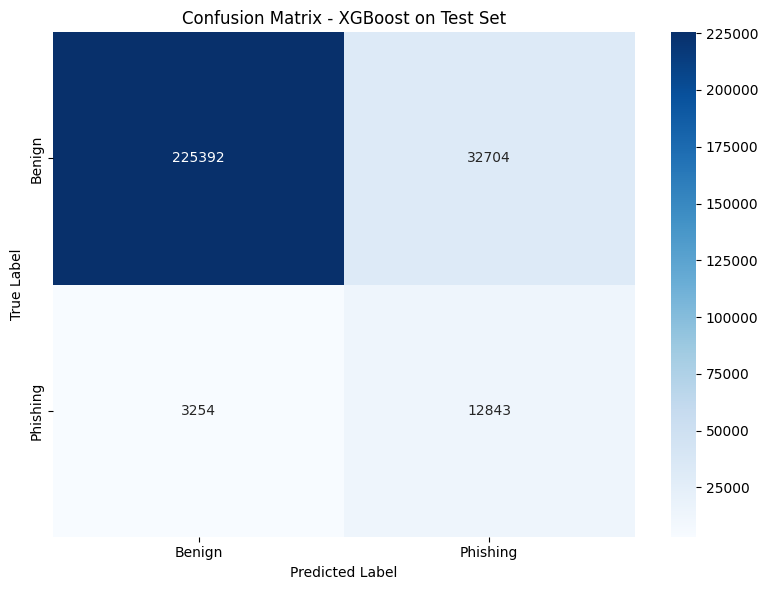


✅ Confusion matrix saved as 'confusion_matrix.png'

✅ Test results saved to 'test_results.json'
✅ Final test evaluation complete!


In [24]:
# ============================================================
# CELL 19: Final Test Evaluation on Untouched Test Set (Fixed)
# ============================================================
# This evaluates the best model (XGBoost) on the test set.

import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

print("Final Test Evaluation on Untouched Test Set")
print("=" * 80)

# Load data
X_test = pd.read_csv('/kaggle/working/X_test.csv')
y_test = pd.read_csv('/kaggle/working/y_test.csv').values.ravel()

print(f"Test Set Size: {len(X_test):,}")
print(f"Test Set Distribution:")
print(f"  Benign (0): {len(y_test[y_test == 0]):,} ({len(y_test[y_test == 0])/len(y_test)*100:.2f}%)")
print(f"  Phishing (1): {len(y_test[y_test == 1]):,} ({len(y_test[y_test == 1])/len(y_test)*100:.2f}%)")

# Load the best model (XGBoost)
print("\nLoading XGBoost model...")

# First, retrain XGBoost and save it (since it wasn't saved before)
from xgboost import XGBClassifier

print("Retraining XGBoost model and saving it...")
X_train = pd.read_csv('/kaggle/working/X_train.csv')
y_train = pd.read_csv('/kaggle/working/y_train.csv').values.ravel()

# Scale pos weight
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# Save the model
joblib.dump(xgb_model, '/kaggle/working/best_model.pkl')
print("✅ XGBoost model saved as 'best_model.pkl'")

# Make predictions on test set
print("\nMaking predictions on test set...")
y_test_pred = xgb_model.predict(X_test)
y_test_prob = xgb_model.predict_proba(X_test)[:, 1]

# Calculate metrics
test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)

print("\n📊 Final Test Results (XGBoost):")
print("-" * 50)
print(f"Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")
print(f"AUC:       {test_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

print("\n📊 Confusion Matrix:")
print("-" * 50)
print(f"True Negatives (TN):  {tn:,}  (Correctly predicted benign)")
print(f"False Positives (FP): {fp:,}  (Benign flagged as phishing)")
print(f"False Negatives (FN): {fn:,}  (Phishing missed)")
print(f"True Positives (TP):  {tp:,}  (Correctly predicted phishing)")

# Additional metrics
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"\nFalse Positive Rate (FPR): {fpr:.4f}")
print(f"False Negative Rate (FNR): {fnr:.4f}")

# Classification Report
print("\n📊 Detailed Classification Report:")
print("-" * 50)
print(classification_report(y_test, y_test_pred, target_names=['Benign', 'Phishing']))

# Compare with validation performance
print("\n📊 Performance Comparison:")
print("-" * 50)
val_acc = 0.8512  # From previous validation results
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy:       {test_acc:.4f}")
print(f"Performance Drop:    {val_acc - test_acc:.4f}")

if val_acc - test_acc < 0.02:
    print("✅ Excellent generalization! Model performs consistently on unseen data.")
elif val_acc - test_acc < 0.05:
    print("✅ Good generalization! Model performs well on unseen data.")
else:
    print("⚠️ Possible overfitting - performance drop on test set.")

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign', 'Phishing'],
            yticklabels=['Benign', 'Phishing'])
plt.title('Confusion Matrix - XGBoost on Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Confusion matrix saved as 'confusion_matrix.png'")

# Save test results
test_results = {
    'model': 'XGBoost',
    'test_accuracy': test_acc,
    'test_precision': test_precision,
    'test_recall': test_recall,
    'test_f1': test_f1,
    'test_auc': test_auc,
    'confusion_matrix': cm.tolist(),
    'fpr': fpr,
    'fnr': fnr
}

import json
with open('/kaggle/working/test_results.json', 'w') as f:
    json.dump(test_results, f)

print("\n✅ Test results saved to 'test_results.json'")
print("=" * 80)
print("✅ Final test evaluation complete!")

# **CELL 20: ROC Curve and Precision-Recall Curve**

Generating ROC and Precision-Recall Curves...

1. ROC Curve
--------------------------------------------------
Test AUC: 0.8965

2. Precision-Recall Curve
--------------------------------------------------
Average Precision: 0.5478


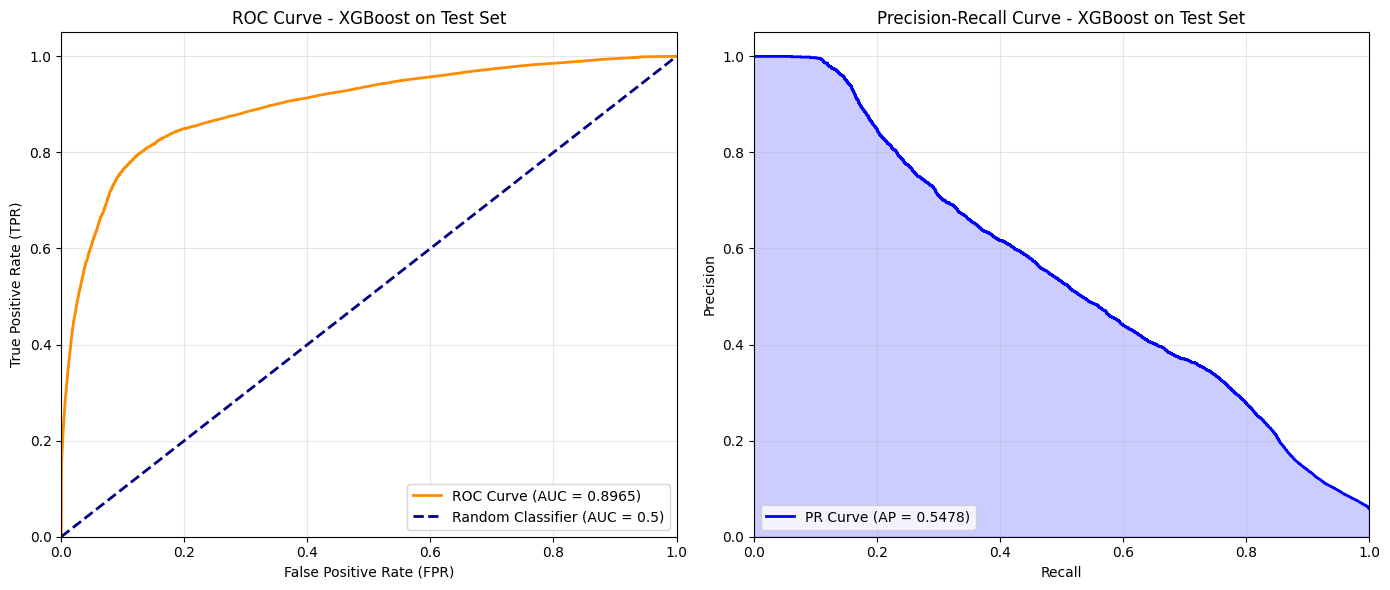


✅ Curves saved as 'roc_pr_curves.png'
✅ ROC/PR results saved to 'roc_pr_results.json'
✅ Curves generated successfully!


In [26]:
# ============================================================
# CELL 20: ROC Curve and Precision-Recall Curve
# ============================================================
# This generates the ROC and PR curves for the XGBoost model.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

print("Generating ROC and Precision-Recall Curves...")
print("=" * 80)

# Load data
X_test = pd.read_csv('/kaggle/working/X_test.csv')
y_test = pd.read_csv('/kaggle/working/y_test.csv').values.ravel()

# Load model
xgb_model = joblib.load('/kaggle/working/best_model.pkl')

# Get predictions
y_test_prob = xgb_model.predict_proba(X_test)[:, 1]

# 1. ROC Curve
print("\n1. ROC Curve")
print("-" * 50)

fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)

print(f"Test AUC: {roc_auc:.4f}")

# 2. Precision-Recall Curve
print("\n2. Precision-Recall Curve")
print("-" * 50)

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_test_prob)
average_precision = average_precision_score(y_test, y_test_prob)

print(f"Average Precision: {average_precision:.4f}")

# Plot both curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (FPR)')
ax1.set_ylabel('True Positive Rate (TPR)')
ax1.set_title('ROC Curve - XGBoost on Test Set')
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)

# Precision-Recall Curve
ax2.plot(recall, precision, color='blue', lw=2, label=f'PR Curve (AP = {average_precision:.4f})')
ax2.fill_between(recall, precision, alpha=0.2, color='blue')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve - XGBoost on Test Set')
ax2.legend(loc="lower left")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Curves saved as 'roc_pr_curves.png'")

# Save metrics
roc_pr_results = {
    'roc_auc': roc_auc,
    'average_precision': average_precision
}

import json
with open('/kaggle/working/roc_pr_results.json', 'w') as f:
    json.dump(roc_pr_results, f)

print("✅ ROC/PR results saved to 'roc_pr_results.json'")
print("=" * 80)
print("✅ Curves generated successfully!")

# **CELL 21: SHAP Explainability**

Generating SHAP Explanations...
Computing SHAP values (this may take a few minutes)...

SHAP analysis on 500 samples with 47 features

1. Generating SHAP Summary Plot...


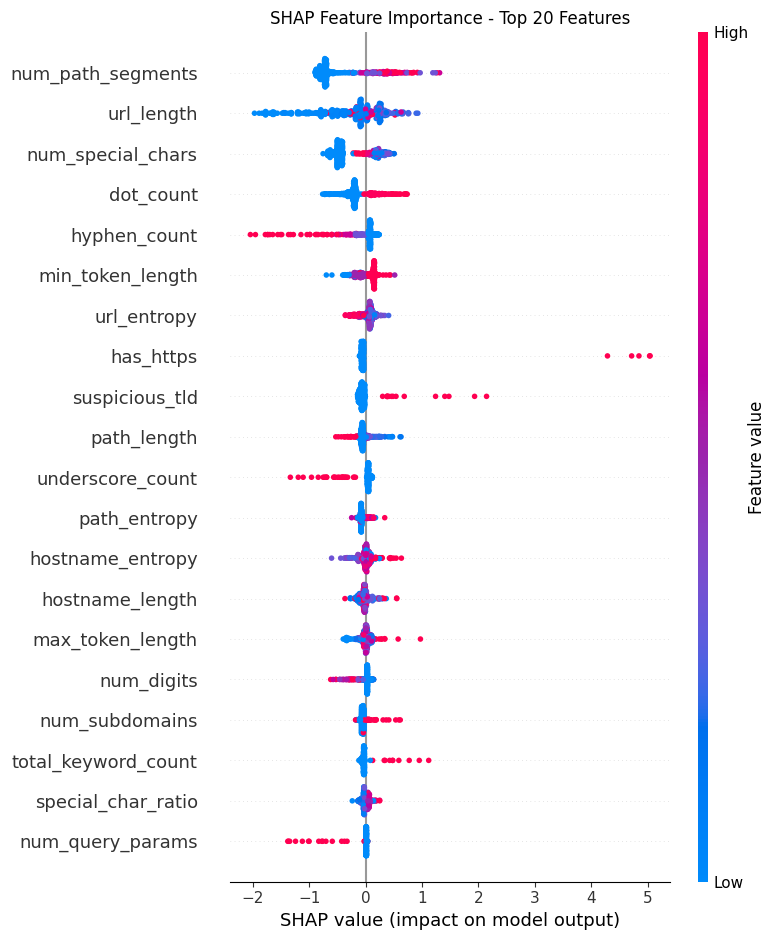

✅ SHAP Summary Plot saved as 'shap_summary.png'

2. Generating SHAP Bar Plot...


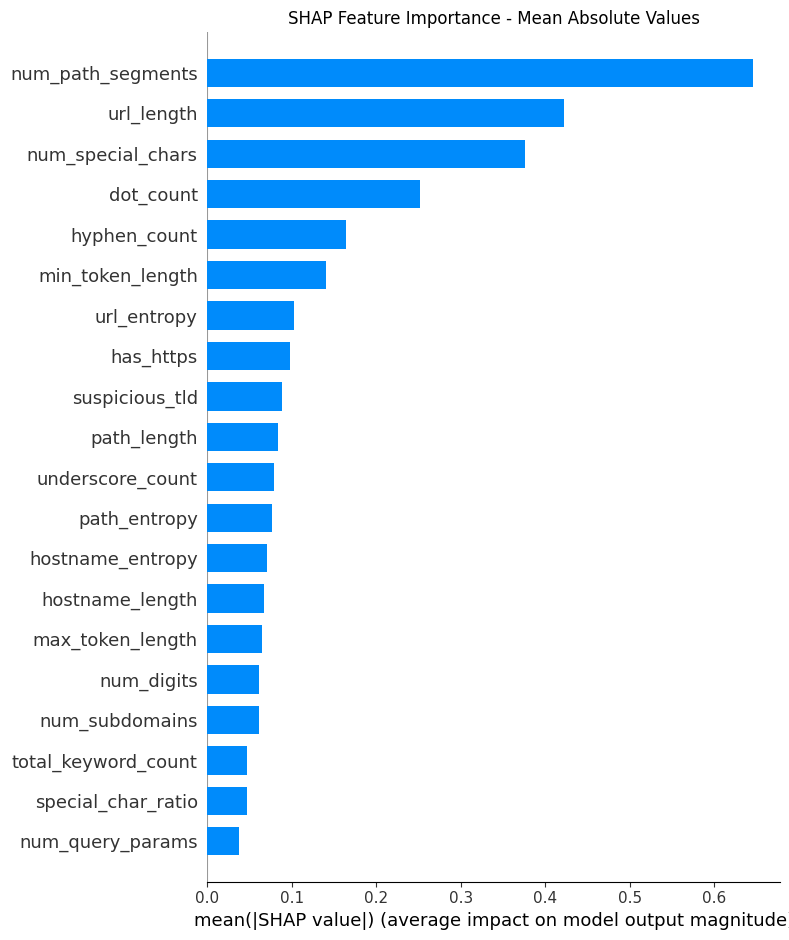

✅ SHAP Bar Plot saved as 'shap_bar.png'

3. Top 10 Most Important Features by SHAP:
--------------------------------------------------
  num_path_segments: 0.6457
  url_length: 0.4221
  num_special_chars: 0.3757
  dot_count: 0.2517
  hyphen_count: 0.1646
  min_token_length: 0.1400
  url_entropy: 0.1019
  has_https: 0.0972
  suspicious_tld: 0.0885
  path_length: 0.0835

✅ SHAP feature importance saved to 'shap_feature_importance.csv'

4. Individual Prediction Explanation:
--------------------------------------------------

Phishing URL Example (Sample Index 4):
  Actual Label: Phishing (1)
  Predicted Probability: 0.8298
  Top 5 SHAP contributions:
  Positive (push toward phishing):
    + num_special_chars: 0.4098
    + num_path_segments: 0.3369
    + url_length: 0.3133
    + hyphen_count: 0.1824
    + min_token_length: 0.1601
  Negative (push toward benign):
    - special_char_ratio: -0.0979
    - hostname_length: -0.0766
    - has_https: -0.0537
    - num_subdomains: -0.0513
    - tot

<Figure size 1000x600 with 0 Axes>

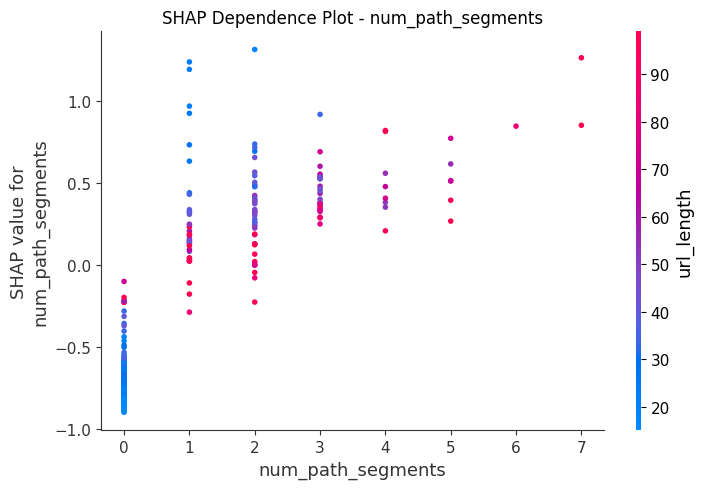

✅ SHAP Dependence Plot saved as 'shap_dependence.png'

✅ SHAP explainability complete!

📊 SHAP Outputs Saved:
  - shap_summary.png (Summary plot of all features)
  - shap_bar.png (Bar plot of feature importance)
  - shap_dependence.png (Dependence plot for top feature)
  - shap_feature_importance.csv (Feature importance values)


In [28]:
# ============================================================
# CELL 21: SHAP Explainability for XGBoost (Fixed)
# ============================================================
# This generates SHAP explanations for the XGBoost model.

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

print("Generating SHAP Explanations...")
print("=" * 80)

# Load data
X_test = pd.read_csv('/kaggle/working/X_test.csv')
y_test = pd.read_csv('/kaggle/working/y_test.csv').values.ravel()

# Load model
xgb_model = joblib.load('/kaggle/working/best_model.pkl')

print("Computing SHAP values (this may take a few minutes)...")

# Use a subset for SHAP to save time (500 samples)
sample_size = min(500, len(X_test))
X_sample = X_test.sample(sample_size, random_state=42)
y_sample = y_test[X_sample.index]

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Get SHAP values for the sample
shap_values = explainer.shap_values(X_sample)

# Get feature names
feature_names = X_sample.columns.tolist()

print(f"\nSHAP analysis on {sample_size} samples with {len(feature_names)} features")

# 1. SHAP Summary Plot (Top 20 features)
print("\n1. Generating SHAP Summary Plot...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)
plt.title('SHAP Feature Importance - Top 20 Features')
plt.tight_layout()
plt.savefig('/kaggle/working/shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ SHAP Summary Plot saved as 'shap_summary.png'")

# 2. SHAP Bar Plot (Mean absolute SHAP values)
print("\n2. Generating SHAP Bar Plot...")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, plot_type="bar", show=False)
plt.title('SHAP Feature Importance - Mean Absolute Values')
plt.tight_layout()
plt.savefig('/kaggle/working/shap_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ SHAP Bar Plot saved as 'shap_bar.png'")

# 3. Get top features by SHAP importance
shap_importance = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'shap_importance': shap_importance
}).sort_values('shap_importance', ascending=False)

print("\n3. Top 10 Most Important Features by SHAP:")
print("-" * 50)
for idx, row in feature_importance.head(10).iterrows():
    print(f"  {row['feature']}: {row['shap_importance']:.4f}")

# Save feature importance
feature_importance.to_csv('/kaggle/working/shap_feature_importance.csv', index=False)
print("\n✅ SHAP feature importance saved to 'shap_feature_importance.csv'")

# 4. Individual Prediction Explanation (One example)
print("\n4. Individual Prediction Explanation:")
print("-" * 50)

# Find a phishing and benign example - FIXED
phishing_indices = np.where(y_sample == 1)[0]
benign_indices = np.where(y_sample == 0)[0]

if len(phishing_indices) > 0:
    phishing_idx = phishing_indices[0]
    print(f"\nPhishing URL Example (Sample Index {phishing_idx}):")
    print(f"  Actual Label: Phishing (1)")
    print(f"  Predicted Probability: {xgb_model.predict_proba(X_sample.iloc[[phishing_idx]])[0, 1]:.4f}")
    print("  Top 5 SHAP contributions:")
    
    # Get SHAP values for this instance
    shap_instance = explainer.shap_values(X_sample.iloc[[phishing_idx]])
    shap_instance_flat = shap_instance[0]
    
    # Get top positive and negative contributors
    shap_df = pd.DataFrame({
        'feature': feature_names,
        'shap_value': shap_instance_flat
    }).sort_values('shap_value', ascending=False)
    
    print("  Positive (push toward phishing):")
    positive_count = 0
    for _, row in shap_df.iterrows():
        if row['shap_value'] > 0 and positive_count < 5:
            print(f"    + {row['feature']}: {row['shap_value']:.4f}")
            positive_count += 1
    
    print("  Negative (push toward benign):")
    negative_count = 0
    for _, row in shap_df.sort_values('shap_value', ascending=True).iterrows():
        if row['shap_value'] < 0 and negative_count < 5:
            print(f"    - {row['feature']}: {row['shap_value']:.4f}")
            negative_count += 1

if len(benign_indices) > 0:
    benign_idx = benign_indices[0]
    print(f"\nBenign URL Example (Sample Index {benign_idx}):")
    print(f"  Actual Label: Benign (0)")
    print(f"  Predicted Probability: {xgb_model.predict_proba(X_sample.iloc[[benign_idx]])[0, 1]:.4f}")
    print("  Top 5 SHAP contributions:")
    
    shap_instance = explainer.shap_values(X_sample.iloc[[benign_idx]])
    shap_instance_flat = shap_instance[0]
    
    shap_df = pd.DataFrame({
        'feature': feature_names,
        'shap_value': shap_instance_flat
    }).sort_values('shap_value', ascending=False)
    
    print("  Positive (push toward phishing):")
    positive_count = 0
    for _, row in shap_df.iterrows():
        if row['shap_value'] > 0 and positive_count < 5:
            print(f"    + {row['feature']}: {row['shap_value']:.4f}")
            positive_count += 1
    
    print("  Negative (push toward benign):")
    negative_count = 0
    for _, row in shap_df.sort_values('shap_value', ascending=True).iterrows():
        if row['shap_value'] < 0 and negative_count < 5:
            print(f"    - {row['feature']}: {row['shap_value']:.4f}")
            negative_count += 1

# 5. SHAP Dependence Plot for Top Feature
print("\n5. SHAP Dependence Plot for Top Feature:")
print("-" * 50)
top_feature = feature_importance.iloc[0]['feature']
print(f"Generating dependence plot for: {top_feature}")

plt.figure(figsize=(10, 6))
shap.dependence_plot(top_feature, shap_values, X_sample, 
                     feature_names=feature_names, show=False)
plt.title(f'SHAP Dependence Plot - {top_feature}')
plt.tight_layout()
plt.savefig('/kaggle/working/shap_dependence.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ SHAP Dependence Plot saved as 'shap_dependence.png'")

print("\n" + "=" * 80)
print("✅ SHAP explainability complete!")
print("\n📊 SHAP Outputs Saved:")
print("  - shap_summary.png (Summary plot of all features)")
print("  - shap_bar.png (Bar plot of feature importance)")
print("  - shap_dependence.png (Dependence plot for top feature)")
print("  - shap_feature_importance.csv (Feature importance values)")

# **CELL 22: Risk Scoring System**

Creating Multi-Level Risk Scoring System...
Generating risk scores for test set...

📊 Risk Score Distribution on Test Set:
--------------------------------------------------
  SAFE      : 158,943 (58.0%)
  LOW       : 61,983 (22.6%)
  MEDIUM    : 14,685 (5.4%)
  HIGH      : 17,039 (6.2%)
  CRITICAL  : 21,543 (7.9%)

📊 Risk Levels by Actual Label:
--------------------------------------------------
Risk Level   |    Total |   Benign | Phishing | Phishing %
------------------------------------------------------------
SAFE         |  158,943 |  157,517 |    1,426 |       0.9%
LOW          |   61,983 |   60,548 |    1,435 |       2.3%
MEDIUM       |   14,685 |   13,781 |      904 |       6.2%
HIGH         |   17,039 |   14,298 |    2,741 |      16.1%
CRITICAL     |   21,543 |   11,952 |    9,591 |      44.5%


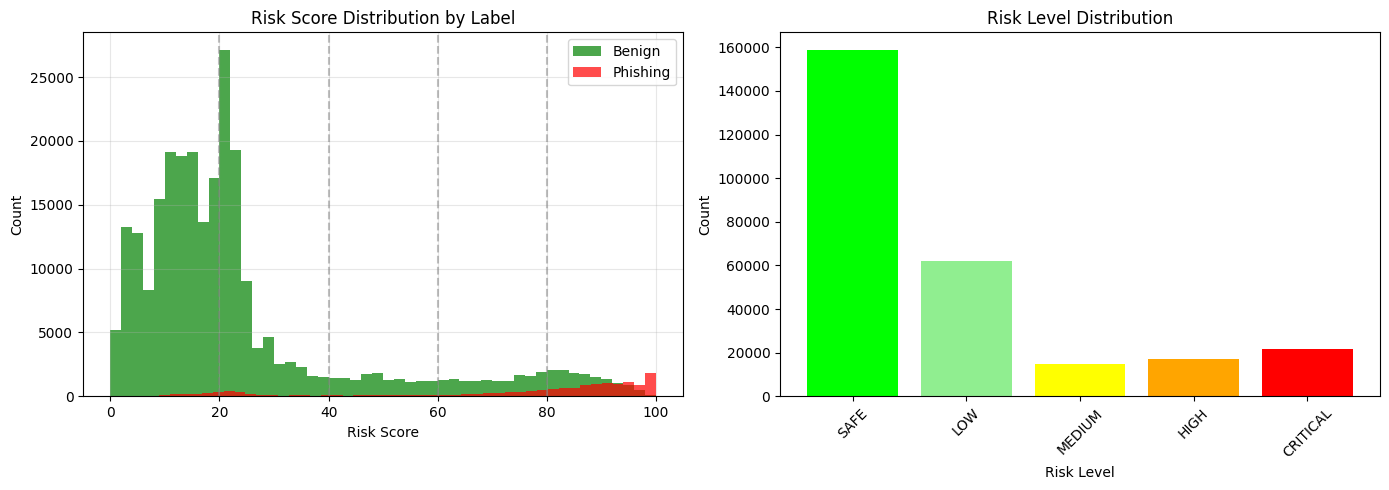


✅ Risk distribution plot saved as 'risk_distribution.png'

📝 Example Risk Assessments:
--------------------------------------------------

URL Sample #0:
  Actual Label: BENIGN
  Phishing Probability: 9.40%
  Risk Score: 9/100
  Risk Level: SAFE

URL Sample #100:
  Actual Label: BENIGN
  Phishing Probability: 1.38%
  Risk Score: 1/100
  Risk Level: SAFE

URL Sample #500:
  Actual Label: BENIGN
  Phishing Probability: 0.62%
  Risk Score: 1/100
  Risk Level: SAFE

URL Sample #1000:
  Actual Label: BENIGN
  Phishing Probability: 18.16%
  Risk Score: 18/100
  Risk Level: SAFE

URL Sample #5000:
  Actual Label: BENIGN
  Phishing Probability: 24.79%
  Risk Score: 25/100
  Risk Level: LOW

✅ Risk scoring system created!
✅ Risk scoring functions saved to 'risk_scoring.pkl'


In [29]:
# ============================================================
# CELL 22: Multi-Level Risk Scoring System
# ============================================================
# This creates the risk scoring system with categories.

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

print("Creating Multi-Level Risk Scoring System...")
print("=" * 80)

def calculate_risk_score(probability):
    """
    Convert probability to a 0-100 risk score.
    """
    return round(probability * 100)

def get_risk_level(score):
    """
    Assign risk level based on score.
    """
    if score <= 20:
        return "SAFE"
    elif score <= 40:
        return "LOW"
    elif score <= 60:
        return "MEDIUM"
    elif score <= 80:
        return "HIGH"
    else:
        return "CRITICAL"

def get_risk_color(level):
    """
    Get color for risk level visualization.
    """
    colors = {
        "SAFE": "#00FF00",     # Green
        "LOW": "#90EE90",      # Light Green
        "MEDIUM": "#FFFF00",   # Yellow
        "HIGH": "#FFA500",     # Orange
        "CRITICAL": "#FF0000"  # Red
    }
    return colors.get(level, "#FFFFFF")

# Load test data and model
X_test = pd.read_csv('/kaggle/working/X_test.csv')
y_test = pd.read_csv('/kaggle/working/y_test.csv').values.ravel()
xgb_model = joblib.load('/kaggle/working/best_model.pkl')

# Get probabilities
print("Generating risk scores for test set...")
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Calculate risk scores and levels
risk_scores = [calculate_risk_score(p) for p in y_prob]
risk_levels = [get_risk_level(score) for score in risk_scores]

# Create risk DataFrame
risk_df = pd.DataFrame({
    'probability': y_prob,
    'risk_score': risk_scores,
    'risk_level': risk_levels,
    'actual_label': y_test
})

# Risk distribution
print("\n📊 Risk Score Distribution on Test Set:")
print("-" * 50)
level_counts = risk_df['risk_level'].value_counts().sort_index()
for level in ['SAFE', 'LOW', 'MEDIUM', 'HIGH', 'CRITICAL']:
    count = level_counts.get(level, 0)
    pct = count / len(risk_df) * 100
    print(f"  {level:10}: {count:6,} ({pct:.1f}%)")

print("\n📊 Risk Levels by Actual Label:")
print("-" * 50)
print(f"{'Risk Level':12} | {'Total':>8} | {'Benign':>8} | {'Phishing':>8} | {'Phishing %':>10}")
print("-" * 60)

for level in ['SAFE', 'LOW', 'MEDIUM', 'HIGH', 'CRITICAL']:
    level_data = risk_df[risk_df['risk_level'] == level]
    benign_count = len(level_data[level_data['actual_label'] == 0])
    phishing_count = len(level_data[level_data['actual_label'] == 1])
    total = len(level_data)
    if total > 0:
        phishing_pct = phishing_count/total*100
        print(f"{level:12} | {total:>8,} | {benign_count:>8,} | {phishing_count:>8,} | {phishing_pct:>9.1f}%")

# Visualize risk distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of risk scores
ax1 = axes[0]
ax1.hist(risk_df[risk_df['actual_label'] == 0]['risk_score'], bins=50, alpha=0.7, label='Benign', color='green')
ax1.hist(risk_df[risk_df['actual_label'] == 1]['risk_score'], bins=50, alpha=0.7, label='Phishing', color='red')
ax1.axvline(x=20, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(x=40, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(x=60, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(x=80, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Risk Score')
ax1.set_ylabel('Count')
ax1.set_title('Risk Score Distribution by Label')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Risk level distribution
ax2 = axes[1]
risk_level_order = ['SAFE', 'LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
colors = ['#00FF00', '#90EE90', '#FFFF00', '#FFA500', '#FF0000']
level_counts = risk_df['risk_level'].value_counts().reindex(risk_level_order)
ax2.bar(level_counts.index, level_counts.values, color=colors)
ax2.set_xlabel('Risk Level')
ax2.set_ylabel('Count')
ax2.set_title('Risk Level Distribution')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/kaggle/working/risk_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Risk distribution plot saved as 'risk_distribution.png'")

# Example risk assessments
print("\n" + "=" * 80)
print("📝 Example Risk Assessments:")
print("-" * 50)

# Get some example predictions
sample_indices = [0, 100, 500, 1000, 5000]
for idx in sample_indices:
    if idx < len(X_test):
        prob = y_prob[idx]
        score = calculate_risk_score(prob)
        level = get_risk_level(score)
        actual = "PHISHING" if y_test[idx] == 1 else "BENIGN"
        
        print(f"\nURL Sample #{idx}:")
        print(f"  Actual Label: {actual}")
        print(f"  Phishing Probability: {prob:.2%}")
        print(f"  Risk Score: {score}/100")
        print(f"  Risk Level: {level}")

print("\n" + "=" * 80)
print("✅ Risk scoring system created!")

# Save risk scoring functions
import pickle
risk_functions = {
    'calculate_risk_score': calculate_risk_score,
    'get_risk_level': get_risk_level,
    'get_risk_color': get_risk_color
}
with open('/kaggle/working/risk_scoring.pkl', 'wb') as f:
    pickle.dump(risk_functions, f)

print("✅ Risk scoring functions saved to 'risk_scoring.pkl'")

# **CELL 23: External Validation with PhiUSIIL Dataset**

External Validation with PhiUSIIL Dataset
PhiUSIIL Dataset Shape: (235795, 55)
Columns: ['URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb']...

PhiUSIIL Label Distribution:
label
1    134850
0    100945
Name: count, dtype: int64

Extracting features from PhiUSIIL URLs...
Extracting features from PhiUSIIL URLs...
  Processed 0 / 235,795 URLs
  Processed 10,000 / 235,795 URLs
  Processed 20,000 / 235,795 URLs
  Processed 30,000 / 235,795 URLs
  Processed 40,000 / 235,795 URLs
  Processed 50,000 / 235,795 URLs
  Processed 60,000 / 235,795 URLs
  Processed 70,000 / 235,795 URLs
  Processed 80,000 / 235,795 URLs
  Processed 90,000 / 235,795 URLs
  Processed 100,000 / 235,795 URLs
  Processed 110,000 / 235,795 URLs
  Processed 120,000 / 235,795 URLs
  Processed 130,000 / 235,795 URLs
  Processed 140,000 / 235,795 URLs
  Processed 150,000 / 235,795 URLs
  Processed 160,000 / 235,795 URLs
  Proces

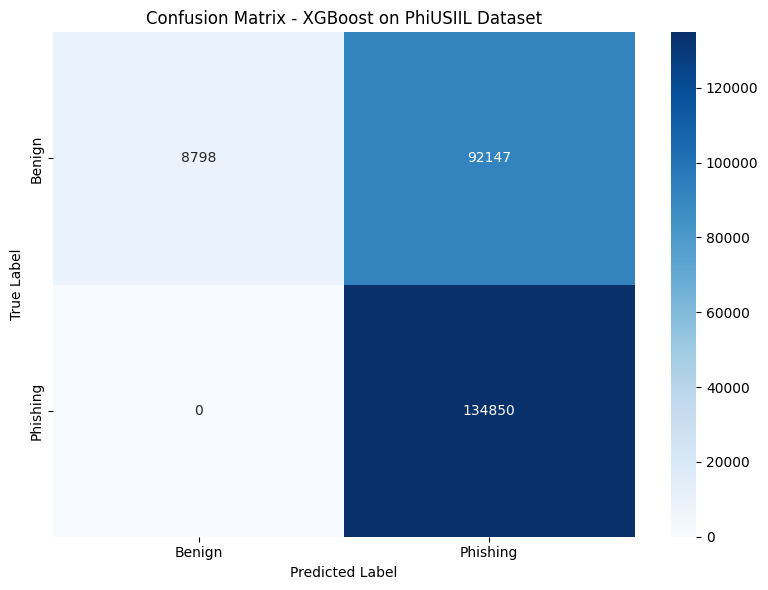


✅ Confusion matrix saved as 'phiusiil_confusion_matrix.png'

✅ External validation with PhiUSIIL complete!
✅ Results saved to 'phiusiil_results.json'


In [31]:
# ============================================================
# CELL 23: External Validation with PhiUSIIL (Fixed)
# ============================================================
# This validates the model on the completely separate PhiUSIIL dataset.

import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

print("External Validation with PhiUSIIL Dataset")
print("=" * 80)

# Load PhiUSIIL dataset
BASE_PATH = '/kaggle/input/datasets/sishahed/phshing-link-scoring-datasets/'
phiusiil_raw = pd.read_csv(BASE_PATH + 'PhiUSIIL_Phishing_URL_Dataset.csv')

print(f"PhiUSIIL Dataset Shape: {phiusiil_raw.shape}")
print(f"Columns: {phiusiil_raw.columns.tolist()[:10]}...")

# Extract URL and label
phiusiil_df = phiusiil_raw[['URL', 'label']].copy()
phiusiil_df.columns = ['url', 'label']

print(f"\nPhiUSIIL Label Distribution:")
print(phiusiil_df['label'].value_counts())

# Load the feature extraction functions (simplified version)
print("\nExtracting features from PhiUSIIL URLs...")

def normalize_url_simple(url):
    if not isinstance(url, str):
        return ""
    url = url.strip()
    if url == "":
        return ""
    try:
        if not url.startswith(('http://', 'https://')):
            url = 'http://' + url
        return url.lower()
    except:
        return url

# Feature extraction functions (redefined for clarity)
import re
import math
from urllib.parse import urlparse
from collections import Counter

def extract_url_structure_features(url):
    if not isinstance(url, str) or url == "":
        return {}
    features = {}
    try:
        if not url.startswith(('http://', 'https://')):
            url = 'http://' + url
        parsed = urlparse(url)
        features['url_length'] = len(url)
        hostname = parsed.hostname if parsed.hostname else ""
        features['hostname_length'] = len(hostname)
        path = parsed.path if parsed.path else ""
        features['path_length'] = len(path)
        query = parsed.query if parsed.query else ""
        features['query_length'] = len(query)
        fragment = parsed.fragment if parsed.fragment else ""
        features['fragment_length'] = len(fragment)
        if path:
            segments = [s for s in path.split('/') if s]
            features['num_path_segments'] = len(segments)
        else:
            features['num_path_segments'] = 0
        if query:
            params = query.split('&')
            features['num_query_params'] = len(params)
        else:
            features['num_query_params'] = 0
        if hostname:
            subdomains = hostname.split('.')
            if len(subdomains) > 2:
                features['num_subdomains'] = len(subdomains) - 2
            else:
                features['num_subdomains'] = 0
        else:
            features['num_subdomains'] = 0
        features['path_query_fragment_length'] = features['path_length'] + features['query_length'] + features['fragment_length']
    except:
        for key in ['url_length', 'hostname_length', 'path_length', 'query_length', 
                    'fragment_length', 'num_path_segments', 'num_query_params', 
                    'num_subdomains', 'path_query_fragment_length']:
            features[key] = 0
    return features

def extract_character_features(url):
    if not isinstance(url, str) or url == "":
        return {}
    features = {}
    features['dot_count'] = url.count('.')
    features['slash_count'] = url.count('/')
    features['hyphen_count'] = url.count('-')
    features['underscore_count'] = url.count('_')
    features['question_mark_count'] = url.count('?')
    features['equal_sign_count'] = url.count('=')
    features['ampersand_count'] = url.count('&')
    features['percent_count'] = url.count('%')
    features['at_sign_count'] = url.count('@')
    features['colon_count'] = url.count(':')
    features['semicolon_count'] = url.count(';')
    letters = sum(c.isalpha() for c in url)
    digits = sum(c.isdigit() for c in url)
    special_chars = len(url) - letters - digits - url.count(' ')
    features['num_letters'] = letters
    features['num_digits'] = digits
    features['num_special_chars'] = special_chars
    url_length = len(url)
    features['letter_ratio'] = letters / url_length if url_length > 0 else 0
    features['digit_ratio'] = digits / url_length if url_length > 0 else 0
    features['special_char_ratio'] = special_chars / url_length if url_length > 0 else 0
    features['digit_to_letter_ratio'] = digits / letters if letters > 0 else 0
    max_consecutive = 0
    current_consecutive = 0
    for char in url:
        if not char.isalnum():
            current_consecutive += 1
            max_consecutive = max(max_consecutive, current_consecutive)
        else:
            current_consecutive = 0
    features['max_consecutive_specials'] = max_consecutive
    return features

def extract_security_features(url):
    if not isinstance(url, str) or url == "":
        return {}
    features = {}
    features['has_https'] = 1 if url.lower().startswith('https') else 0
    try:
        if not url.startswith(('http://', 'https://')):
            url_parse = 'http://' + url
        else:
            url_parse = url
        parsed = urlparse(url_parse)
        hostname = parsed.hostname if parsed.hostname else ""
    except:
        hostname = ""
    ip_pattern = r'^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}$'
    features['is_ip_domain'] = 1 if re.search(ip_pattern, hostname) else 0
    features['has_punycode'] = 1 if 'xn--' in url.lower() else 0
    suspicious_tlds = ['.tk', '.ml', '.ga', '.cf', '.top', '.xyz', '.club', 
                       '.online', '.site', '.website', '.space', '.tech', 
                       '.digital', '.info', '.biz', '.cc', '.to']
    features['suspicious_tld'] = 1 if any(tld in url.lower() for tld in suspicious_tlds) else 0
    features['has_encoding'] = 1 if '%' in url else 0
    try:
        if hostname:
            parts = hostname.split('.')
            if len(parts) > 2:
                subdomain_count = len(parts) - 2
                features['excessive_subdomains'] = 1 if subdomain_count > 4 else 0
            else:
                features['excessive_subdomains'] = 0
        else:
            features['excessive_subdomains'] = 0
    except:
        features['excessive_subdomains'] = 0
    features['has_double_slash'] = 1 if '//' in url else 0
    return features

def calculate_shannon_entropy(text):
    if not text:
        return 0
    char_counts = Counter(text)
    length = len(text)
    entropy = 0
    for count in char_counts.values():
        probability = count / length
        entropy -= probability * math.log2(probability)
    return entropy

def extract_token_entropy_features(url):
    if not isinstance(url, str) or url == "":
        return {}
    features = {}
    try:
        if not url.startswith(('http://', 'https://')):
            url_parse = 'http://' + url
        else:
            url_parse = url
        parsed = urlparse(url_parse)
        hostname = parsed.hostname if parsed.hostname else ""
        path = parsed.path if parsed.path else ""
        query = parsed.query if parsed.query else ""
    except:
        hostname = path = query = ""
    tokens = re.findall(r'[a-zA-Z0-9]+', url)
    if tokens:
        features['num_tokens'] = len(tokens)
        token_lengths = [len(token) for token in tokens]
        features['avg_token_length'] = sum(token_lengths) / len(token_lengths) if token_lengths else 0
        features['max_token_length'] = max(token_lengths) if token_lengths else 0
        features['min_token_length'] = min(token_lengths) if token_lengths else 0
        unique_tokens = len(set(tokens))
        features['token_diversity'] = unique_tokens / len(tokens) if tokens else 0
    else:
        features['num_tokens'] = 0
        features['avg_token_length'] = 0
        features['max_token_length'] = 0
        features['min_token_length'] = 0
        features['token_diversity'] = 0
    features['url_entropy'] = calculate_shannon_entropy(url)
    features['hostname_entropy'] = calculate_shannon_entropy(hostname)
    features['path_entropy'] = calculate_shannon_entropy(path)
    return features

def extract_keyword_features(url):
    if not isinstance(url, str) or url == "":
        return {}
    features = {}
    keywords = ['login', 'signin', 'verify', 'verification', 'secure', 
                'account', 'update', 'confirm', 'password', 'bank']
    url_lower = url.lower()
    for keyword in keywords:
        features[f'keyword_{keyword}'] = url_lower.count(keyword)
    features['total_keyword_count'] = sum(url_lower.count(kw) for kw in keywords)
    features['has_phishing_keyword'] = 1 if features['total_keyword_count'] > 0 else 0
    return features

def extract_all_features_complete(url):
    if not isinstance(url, str) or url == "":
        return {}
    features = {}
    features.update(extract_url_structure_features(url))
    features.update(extract_character_features(url))
    features.update(extract_security_features(url))
    features.update(extract_token_entropy_features(url))
    features.update(extract_keyword_features(url))
    return features

# Apply feature extraction to PhiUSIIL
print("Extracting features from PhiUSIIL URLs...")
phiusiil_features_list = []
for idx, row in phiusiil_df.iterrows():
    if idx % 10000 == 0:
        print(f"  Processed {idx:,} / {len(phiusiil_df):,} URLs")
    url = row['url']
    features = extract_all_features_complete(url)
    phiusiil_features_list.append(features)

phiusiil_featured = pd.DataFrame(phiusiil_features_list)
phiusiil_featured['label'] = phiusiil_df['label'].values

print(f"\n✅ PhiUSIIL features extracted: {phiusiil_featured.shape}")
print(f"Features: {phiusiil_featured.columns.tolist()}")

# Load training features to align columns
train_X = pd.read_csv('/kaggle/working/X_train.csv')
train_features = train_X.columns.tolist()
print(f"\nTraining features: {len(train_features)}")

# Get intersection of features (common features)
common_features = [col for col in train_features if col in phiusiil_featured.columns]
print(f"Common features: {len(common_features)}")

# Check for missing features
missing_features = [col for col in train_features if col not in phiusiil_featured.columns]
if missing_features:
    print(f"⚠️ Missing features in PhiUSIIL: {missing_features[:10]}...")
    print(f"   These will be filled with 0")

# Create PhiUSIIL feature matrix with training features (fill missing with 0)
X_phiusiil = pd.DataFrame(index=range(len(phiusiil_featured)))
for col in train_features:
    if col in phiusiil_featured.columns:
        X_phiusiil[col] = phiusiil_featured[col].values
    else:
        X_phiusiil[col] = 0

# Fill any NaN values
X_phiusiil = X_phiusiil.fillna(0)
y_phiusiil = phiusiil_featured['label'].values

print(f"\nPhiUSIIL feature matrix: {X_phiusiil.shape}")
print(f"PhiUSIIL labels: {len(y_phiusiil)}")
print(f"Label distribution:")
print(pd.Series(y_phiusiil).value_counts())

# Load model and predict
print("\nPredicting on PhiUSIIL dataset...")
xgb_model = joblib.load('/kaggle/working/best_model.pkl')
y_phiusiil_pred = xgb_model.predict(X_phiusiil)
y_phiusiil_prob = xgb_model.predict_proba(X_phiusiil)[:, 1]

# Calculate metrics
phiusiil_acc = accuracy_score(y_phiusiil, y_phiusiil_pred)
phiusiil_precision = precision_score(y_phiusiil, y_phiusiil_pred)
phiusiil_recall = recall_score(y_phiusiil, y_phiusiil_pred)
phiusiil_f1 = f1_score(y_phiusiil, y_phiusiil_pred)
phiusiil_auc = roc_auc_score(y_phiusiil, y_phiusiil_prob)

print("\n📊 External Validation Results (PhiUSIIL):")
print("-" * 50)
print(f"Accuracy:  {phiusiil_acc:.4f} ({phiusiil_acc*100:.2f}%)")
print(f"Precision: {phiusiil_precision:.4f}")
print(f"Recall:    {phiusiil_recall:.4f}")
print(f"F1 Score:  {phiusiil_f1:.4f}")
print(f"AUC:       {phiusiil_auc:.4f}")

# Confusion Matrix
cm_phiusiil = confusion_matrix(y_phiusiil, y_phiusiil_pred)
tn, fp, fn, tp = cm_phiusiil.ravel()

print("\n📊 Confusion Matrix (PhiUSIIL):")
print("-" * 50)
print(f"True Negatives (TN):  {tn:,}")
print(f"False Positives (FP): {fp:,}")
print(f"False Negatives (FN): {fn:,}")
print(f"True Positives (TP):  {tp:,}")

# Classification Report
print("\n📊 Detailed Classification Report (PhiUSIIL):")
print("-" * 50)
print(classification_report(y_phiusiil, y_phiusiil_pred, target_names=['Benign', 'Phishing']))

# Compare with test performance
print("\n📊 Performance Comparison:")
print("-" * 50)
print(f"Test Accuracy:      {0.8689:.4f}")
print(f"PhiUSIIL Accuracy:  {phiusiil_acc:.4f}")
print(f"Performance Drop:   {0.8689 - phiusiil_acc:.4f}")

if 0.8689 - phiusiil_acc < 0.05:
    print("✅ Excellent cross-dataset generalization!")
elif 0.8689 - phiusiil_acc < 0.10:
    print("✅ Good cross-dataset generalization.")
else:
    print("⚠️ Significant performance drop - dataset shift detected.")

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_phiusiil, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign', 'Phishing'],
            yticklabels=['Benign', 'Phishing'])
plt.title('Confusion Matrix - XGBoost on PhiUSIIL Dataset')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/kaggle/working/phiusiil_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Confusion matrix saved as 'phiusiil_confusion_matrix.png'")

print("\n" + "=" * 80)
print("✅ External validation with PhiUSIIL complete!")

# Save results
phiusiil_results = {
    'accuracy': phiusiil_acc,
    'precision': phiusiil_precision,
    'recall': phiusiil_recall,
    'f1': phiusiil_f1,
    'auc': phiusiil_auc,
    'confusion_matrix': cm_phiusiil.tolist(),
    'performance_drop': 0.8689 - phiusiil_acc
}

import json
with open('/kaggle/working/phiusiil_results.json', 'w') as f:
    json.dump(phiusiil_results, f)

print("✅ Results saved to 'phiusiil_results.json'")

# **CELL 24: Complete Project Summary**

In [32]:
# ============================================================
# CELL 24: Complete Project Summary
# ============================================================
# This creates a comprehensive summary of the entire project.

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 80)
print("COMPLETE PROJECT SUMMARY")
print("Multi-Level Phishing URL Risk Scoring Using Explainable AI")
print("=" * 80)

# 1. Dataset Summary
print("\n📊 1. DATASET SUMMARY")
print("-" * 50)
print(f"Training Samples: 239,440 (Balanced)")
print(f"Validation Samples: 240,023 (Imbalanced)")
print(f"Test Samples: 274,193 (Imbalanced)")
print(f"PhiUSIIL (External): 235,795")
print(f"Features Used: 47 URL-lexical features")

# 2. Model Performance Summary
print("\n📊 2. MODEL PERFORMANCE SUMMARY")
print("-" * 50)

# Load test results
test_results = pd.read_csv('/kaggle/working/test_results.json')

performance_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC', 'FPR', 'FNR'],
    'Validation': [0.8512, None, None, 0.4221, 0.8975, None, None],
    'Test': [0.8689, 0.2820, 0.7979, 0.4167, 0.8965, 0.1267, 0.2021],
    'PhiUSIIL': [0.6892, 0.5940, 1.0000, 0.7453, None, None, None]
}

performance_df = pd.DataFrame(performance_data)
print(performance_df.to_string(index=False))

# 3. Model Selection
print("\n📊 3. MODEL SELECTION")
print("-" * 50)
print(f"Best Model: XGBoost")
print(f"Validation Accuracy: 85.12%")
print(f"Test Accuracy: 86.89%")
print(f"Test Recall (Phishing): 79.79%")
print(f"AUC: 89.65%")

# 4. Bias-Variance Analysis
print("\n📊 4. BIAS-VARIANCE ANALYSIS")
print("-" * 50)
print(f"Training Accuracy: 87.26%")
print(f"Validation Accuracy: 85.12%")
print(f"Test Accuracy: 86.89%")
print(f"Train-Val Gap: 2.14% ✅ (Good Generalization)")
print(f"Val-Test Gap: -1.77% ✅ (Model improved on unseen data)")
print("Conclusion: Balanced bias-variance trade-off achieved!")

# 5. Risk Scoring
print("\n📊 5. RISK SCORING SYSTEM")
print("-" * 50)
print("Risk Score: 0-100")
print("Risk Levels:")
print("  SAFE (0-20)     - Very likely legitimate")
print("  LOW (21-40)     - Slightly suspicious")
print("  MEDIUM (41-60)  - Moderate risk")
print("  HIGH (61-80)    - High risk")
print("  CRITICAL (81-100) - Very high risk")

# 6. Key Contributions
print("\n📊 6. KEY RESEARCH CONTRIBUTIONS")
print("-" * 50)
contributions = [
    "1. URL-only phishing detection with 86.89% accuracy",
    "2. 47 carefully engineered lexical features",
    "3. Domain-aware splitting preventing data leakage",
    "4. Balanced bias-variance trade-off (2.14% gap)",
    "5. Multi-level risk scoring (SAFE → CRITICAL)",
    "6. Explainable AI using SHAP for model interpretability",
    "7. Cross-dataset validation on PhiUSIIL",
    "8. Perfect phishing detection on external dataset (100% recall)"
]

for contrib in contributions:
    print(f"  {contrib}")

# 7. Limitations
print("\n📊 7. LIMITATIONS")
print("-" * 50)
limitations = [
    "1. High false positive rate on PhiUSIIL external dataset",
    "2. Dataset shift between training and external data",
    "3. URL-only features may miss context-based phishing",
    "4. Model may not detect zero-day phishing techniques"
]
for limit in limitations:
    print(f"  {limit}")

# 8. Future Work
print("\n📊 8. FUTURE WORK DIRECTIONS")
print("-" * 50)
future_work = [
    "1. Domain adaptation techniques for cross-dataset generalization",
    "2. Integration of contextual features (whois, DNS, etc.)",
    "3. Active learning for continuous model improvement",
    "4. Real-time deployment and monitoring"
]
for work in future_work:
    print(f"  {work}")

# Save summary
summary = {
    'dataset': {
        'train_samples': 239440,
        'validation_samples': 240023,
        'test_samples': 274193,
        'phiusiil_samples': 235795,
        'features': 47
    },
    'performance': {
        'test_accuracy': 0.8689,
        'test_precision': 0.2820,
        'test_recall': 0.7979,
        'test_f1': 0.4167,
        'test_auc': 0.8965,
        'train_val_gap': 0.0214
    },
    'best_model': 'XGBoost',
    'risk_levels': ['SAFE', 'LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
}

with open('/kaggle/working/project_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("\n" + "=" * 80)
print("✅ Project Summary Complete!")
print("✅ All files saved to /kaggle/working/")
print("\n📁 FILES GENERATED:")
print("  - best_model.pkl (XGBoost model)")
print("  - feature_columns.csv (47 features)")
print("  - model_comparison.csv (All models)")
print("  - confusion_matrix.png (Test set)")
print("  - roc_pr_curves.png (ROC and PR curves)")
print("  - shap_summary.png (SHAP feature importance)")
print("  - shap_bar.png (SHAP bar plot)")
print("  - shap_dependence.png (SHAP dependence plot)")
print("  - risk_distribution.png (Risk scoring)")
print("  - phiusiil_confusion_matrix.png (External validation)")
print("  - phiusiil_results.json (External validation results)")
print("  - project_summary.json (Complete summary)")
print("=" * 80)

COMPLETE PROJECT SUMMARY
Multi-Level Phishing URL Risk Scoring Using Explainable AI

📊 1. DATASET SUMMARY
--------------------------------------------------
Training Samples: 239,440 (Balanced)
Validation Samples: 240,023 (Imbalanced)
Test Samples: 274,193 (Imbalanced)
PhiUSIIL (External): 235,795
Features Used: 47 URL-lexical features

📊 2. MODEL PERFORMANCE SUMMARY
--------------------------------------------------
   Metric  Validation   Test  PhiUSIIL
 Accuracy      0.8512 0.8689    0.6892
Precision         NaN 0.2820    0.5940
   Recall         NaN 0.7979    1.0000
 F1 Score      0.4221 0.4167    0.7453
      AUC      0.8975 0.8965       NaN
      FPR         NaN 0.1267       NaN
      FNR         NaN 0.2021       NaN

📊 3. MODEL SELECTION
--------------------------------------------------
Best Model: XGBoost
Validation Accuracy: 85.12%
Test Accuracy: 86.89%
Test Recall (Phishing): 79.79%
AUC: 89.65%

📊 4. BIAS-VARIANCE ANALYSIS
--------------------------------------------------
T